# Objectif du notebook 

Date de création : 03/06/2026

Extraction de signaux reçu pour analyse par time-warping selon le tutoriel de J.Bonnel 

In [66]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.io.wavfile as wavfile

from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [67]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [68]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)

from source.rtf_mfp.rtf_mfp_plot_utils import plot_sequence_spectrogram
from misc import BandFilter
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
# from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import (
#     plot_seq_replica_positions, plot
# )
from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import (
    plot_speed_along_seq,
    plot_seq_replica_positions_wgs84,
    plot_seq_replica_positions,
)

# Étape 1 : sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [69]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load bathy data
ds_bathy = xr.open_dataset(os.path.join(data_folder, "bathy.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [70]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# # Select only pulses emitted between OBS1 and OBS3
# pulse_slice = (0, 40)     # Only between OBS1 and OBS3
pulse_slice = (400, 500)     # Only between OBS1 and OBS3

df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

In [71]:
print(f"Signal properties for sequence {seq_id}:")
print(f"\tNumber of pulses: {len(df_seq['pulse_id'].unique())}")
print(f"\tSignal type: {df_seq['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq['repeat_period_s'].iloc[0]} seconds")


Signal properties for sequence 144:
	Number of pulses: 100
	Signal type: chirp
	Minimum frequency: 80.0 Hz
	Maximum frequency: 1000.0 Hz
	Signal duration: 5.0 seconds
	Repeat period: 8.0 seconds


# Étape 2 : calcul du vecteur de RTFs
Le vecteur de RTF est estimé pour chaque position de la source à l'aide de la méthode CS-EVD et par déconvolution. 

## Définition des paramètres du processeur

In [72]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 2
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study
    "tau_rtf_analysis": 8.1,
    "alpha_overlap": 0.95,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

## Calcul des RTFs

In [73]:
###########################
# Library
###########################
id_library = 150

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# rtf_mfp_processor.compute_library(
#     active_feature_args=active_replicas_args,
#     passive_feature_args=passive_replicas_args,
#     id=id_library,
# )

## Chargement des données 

In [74]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_150.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 36MB
Dimensions:           (h_index: 3, f_rtf: 8193, replica_id: 99, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int64 24B 1 2 3
  * f_rtf             (f_rtf) float32 33kB 0.0 0.1221 0.2441 ... 999.9 1e+03
  * replica_id        (replica_id) int64 792B 0 1 2 3 4 5 ... 93 94 95 96 97 98
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 10MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 10MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 6MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 6MB ...
    feature_psd       (f_rtf, replica_id) float32 3MB ...
    e_replica         (replica_id) float32 396B ...
    n_replica         (replica_id) float32 396B ...
    u_replica         (replica_id) float32 396B ...
    replica_type      (replica_id) int64 792B ...
Attributes: (12/16)
    reference_receiver_id:  2
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     150

In [75]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 142MB
Dimensions:                     (h_index: 3, time: 1616182, pulse_id: 99,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 8193,
                                 f_csdm: 8193, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 6MB 0.0 0.0005 ... 808.1 808.1
  * pulse_id                    (pulse_id) int64 792B 400 401 402 ... 498 499
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
Data variables:
    signal                      (h_index, time) float32 19MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 1kB ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 13MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 6MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 6MB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 10MB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 10MB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 29MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 29MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 6MB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 6MB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        5.2005
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_11-44-26
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

## Illustration de la donnée d'entrée 

### Position de la source le long de la trajectoire 

In [76]:
e1 = ds_gps.attrs[f"obs1_e_apriori"]
n1 = ds_gps.attrs[f"obs1_n_apriori"]
e2 = ds_gps.attrs[f"obs2_e_apriori"]
n2 = ds_gps.attrs[f"obs2_n_apriori"]
e3 = ds_gps.attrs[f"obs3_e_apriori"]
n3 = ds_gps.attrs[f"obs3_n_apriori"]

d_12 = np.sqrt((e2 - e1)**2 + (n2 - n1)**2)
d_13 = np.sqrt((e3 - e1) ** 2 + (n3 - n1) ** 2)
d_23 = np.sqrt((e2 - e3) ** 2 + (n2 - n3) ** 2)

print(f"Distance OBS 1 - OBS 2 : d_12 = {d_12:.2f} m")
print(f"Distance OBS 1 - OBS 3 : d_13 = {d_13:.2f} m")
print(f"Distance OBS 2 - OBS 3 : d_23 = {d_23:.2f} m")

Distance OBS 1 - OBS 2 : d_12 = 899.54 m
Distance OBS 1 - OBS 3 : d_13 = 1844.66 m
Distance OBS 2 - OBS 3 : d_23 = 947.85 m


(<Figure size 1400x1000 with 4 Axes>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>,
 <GeoAxes: xlabel='Longitude [°]', ylabel='Latitude [°]'>)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


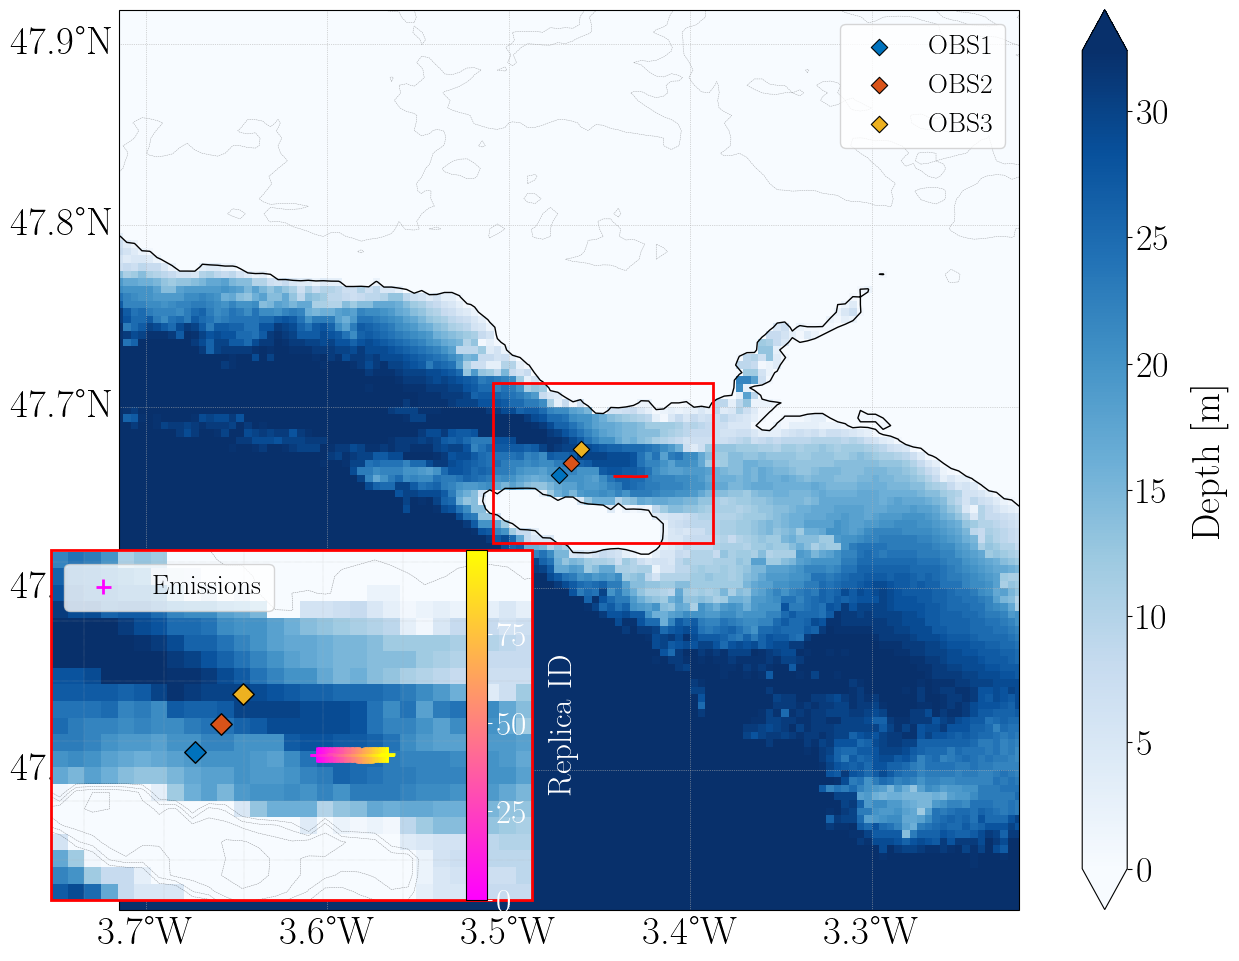

In [77]:
# plot_seq_replica_positions(df_seq, ds_gps, root_fig=None)
plot_seq_replica_positions_wgs84(df_seq, ds_gps, ds_bathy, root_fig=None)

### Vitesse du porteur au cours de la trajectoire 

Median source speed along traj : vs = 1.61 m.s-1
Std source speed along traj : vs = 0.30 m.s-1


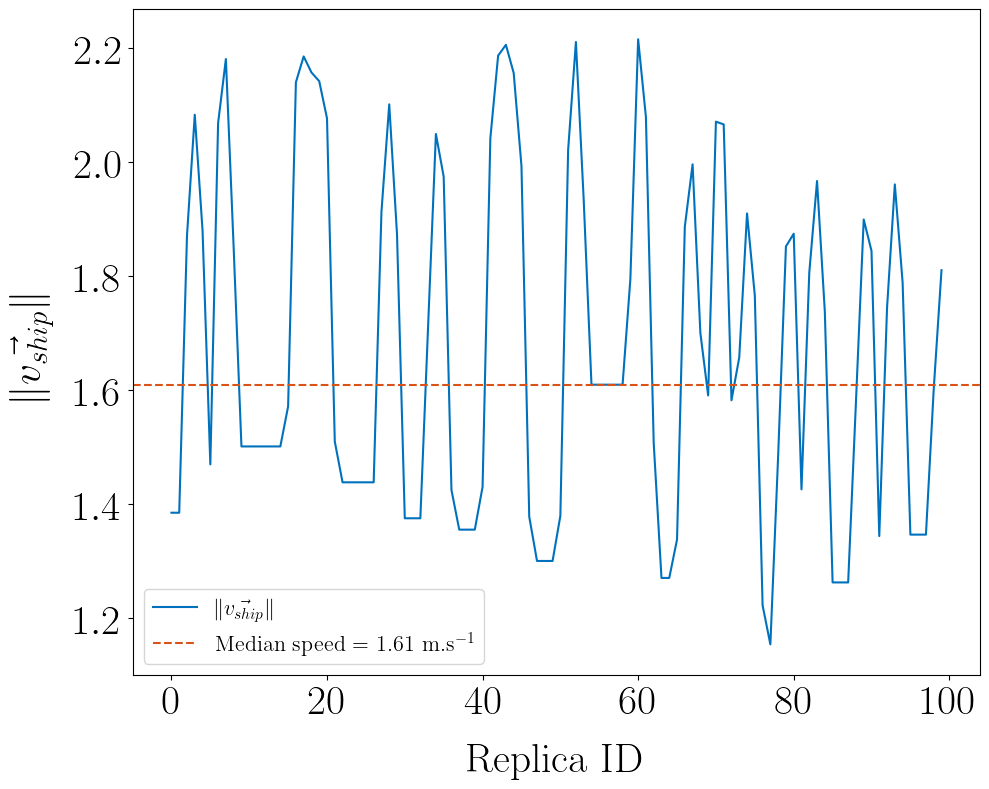

In [78]:
plot_speed_along_seq(df_seq, root_fig=None)

### Profondeur de la source 

In [79]:
fpath_rbr = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\fiberscope_groix_oct_2025\RBR\207416_20251016_1535_data.csv"
df_rbr = pd.read_csv(fpath_rbr, header=0, delimiter=",")
df_rbr["datetime"] = pd.to_datetime(df_rbr[df_rbr.columns[0]])  # Format is explicit 

# Slice the required sequence
df_rbr_seq = df_rbr.loc[
    df_rbr["datetime"].between(
        df_seq["emission_datetime"].min(), df_seq["emission_datetime"].max()
    )
]

Source depth variations during sequence 144:
	Minimum depth: 9.81 m
	Maximum depth: 10.40 m
	Median depth: 10.04 m


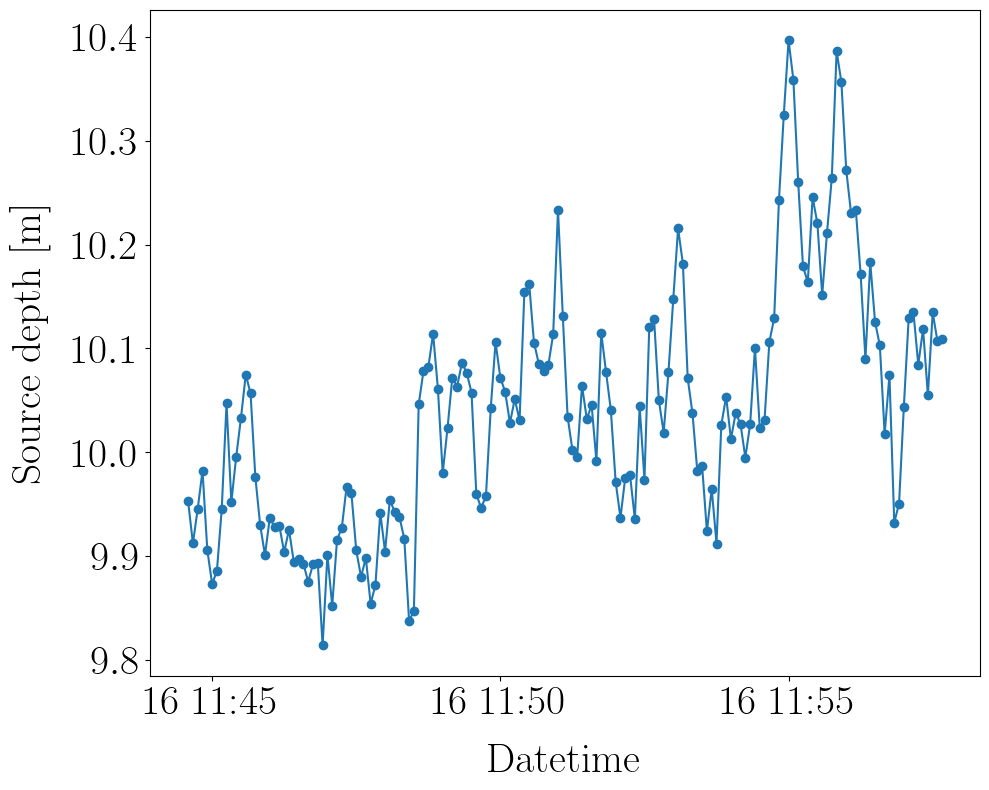

In [80]:
# Plot depth variations along the sequence
plt.figure()
plt.plot(df_rbr_seq["datetime"], df_rbr_seq["Depth [m]"], marker="o")
plt.xlabel("Datetime")
plt.ylabel("Source depth [m]")

print(f"Source depth variations during sequence {seq_id}:")
print(f"\tMinimum depth: {df_rbr_seq['Depth [m]'].min():.2f} m")
print(f"\tMaximum depth: {df_rbr_seq['Depth [m]'].max():.2f} m")
print(f"\tMedian depth: {df_rbr_seq['Depth [m]'].median():.2f} m")

### Données des OBS 

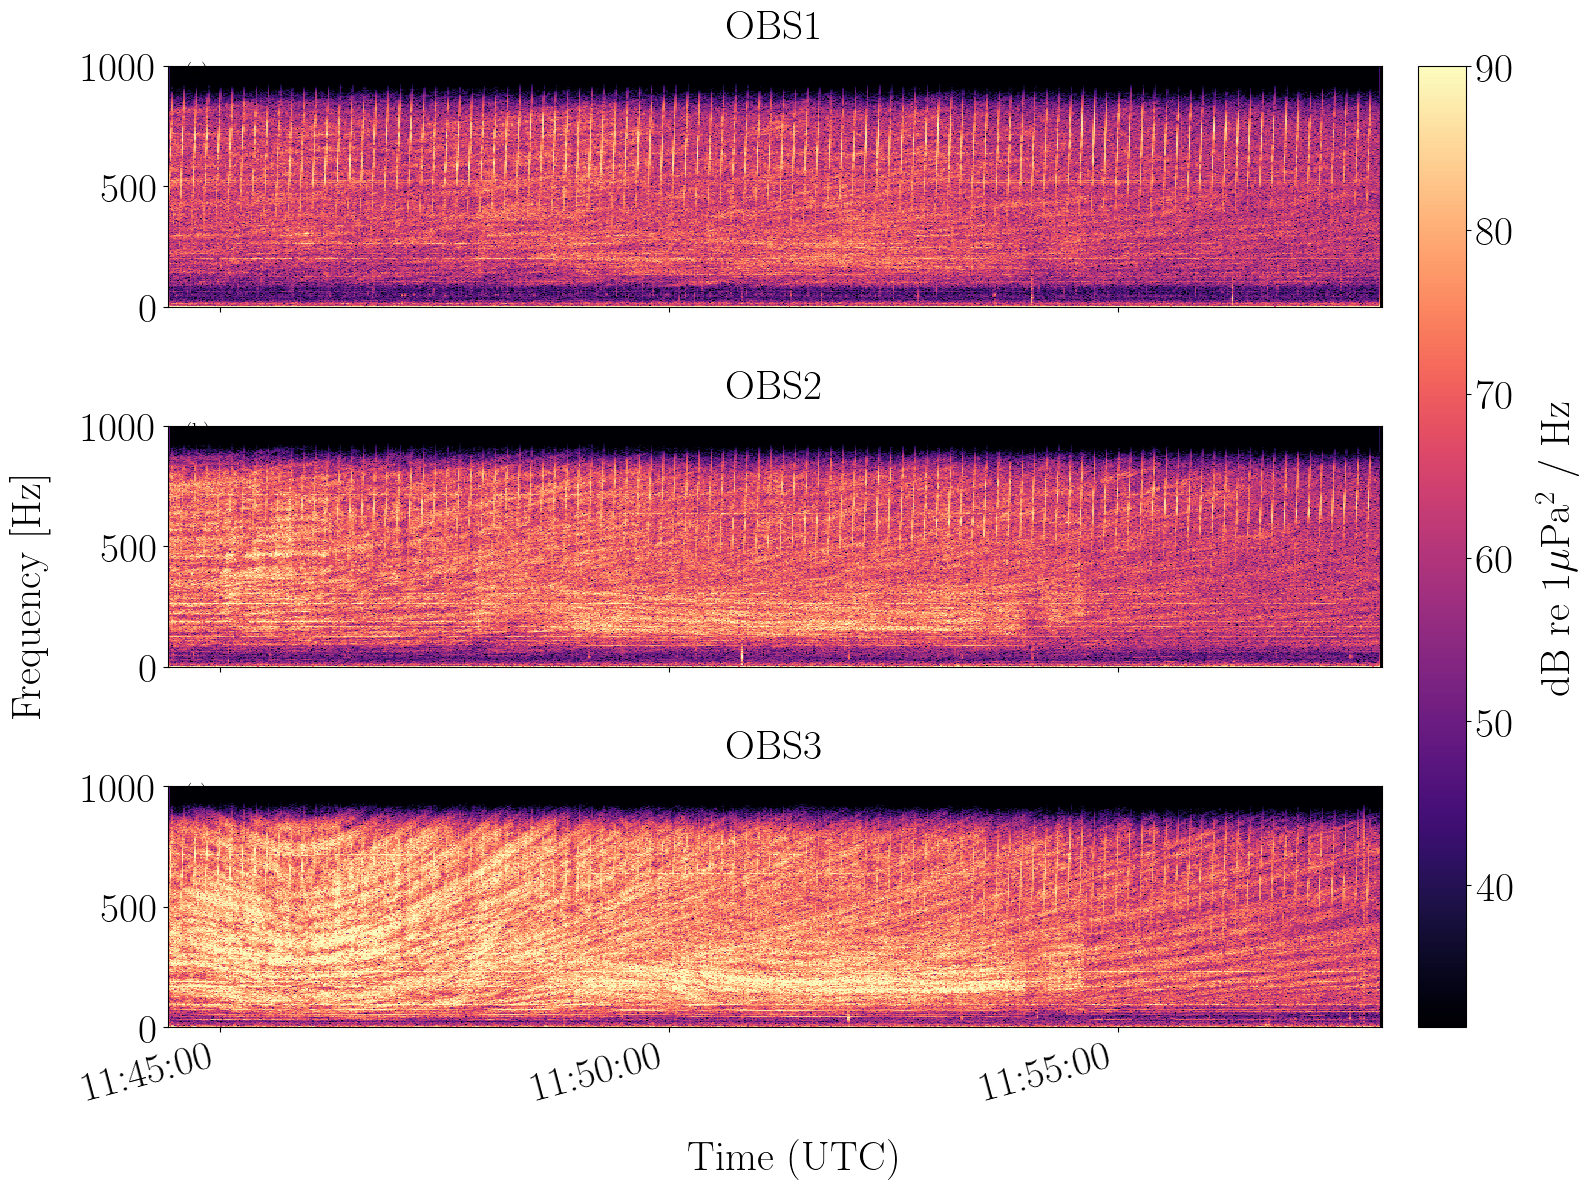

In [81]:
fmin = 0
fmax = 1000
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))


datetime_fmt = ds_sig.attrs["datetime_format"]
t_start = ds_sig.attrs[f"start_datetime"] 
sequence_start_dt = datetime.strptime(t_start, datetime_fmt)
sequence_end_dt = sequence_start_dt + timedelta(
    seconds=int(np.ceil(np.max(ds_sig.time.values)))
)

# sequence_start_dt =
# sequence_end_dt =

plot_sequence_spectrogram(
    ds_wav,
    sequence_start_dt,
    sequence_end_dt,
    savefig=False,
    fig_folder=None,
    nperseg=2**12,
    noverlap=2**11,
    fmin=fmin,
    fmax=fmax,
    # fname="spectro_3obs",
)


# Selection d'une émission 

In [1]:
pulse_id_selected = 400
df_seq_selection = df_seq.loc[df_seq["pulse_id"] == pulse_id_selected]

print(f"Signal properties for selected pulse N°{pulse_id_selected} within sequence {seq_id}:")
print(f"\tSignal type: {df_seq_selection['signal_type'].iloc[0]}")
print(f"\tMinimum frequency: {df_seq_selection['frequency_min_hz'].iloc[0]} Hz")
print(f"\tMaximum frequency: {df_seq_selection['frequency_max_hz'].iloc[0]} Hz")
print(f"\tSignal duration: {df_seq_selection['duration_s'].iloc[0]} seconds")
print(f"\tRepeat period: {df_seq_selection['repeat_period_s'].iloc[0]} seconds")

NameError: name 'df_seq' is not defined

## Position de l'émission sélectionnée

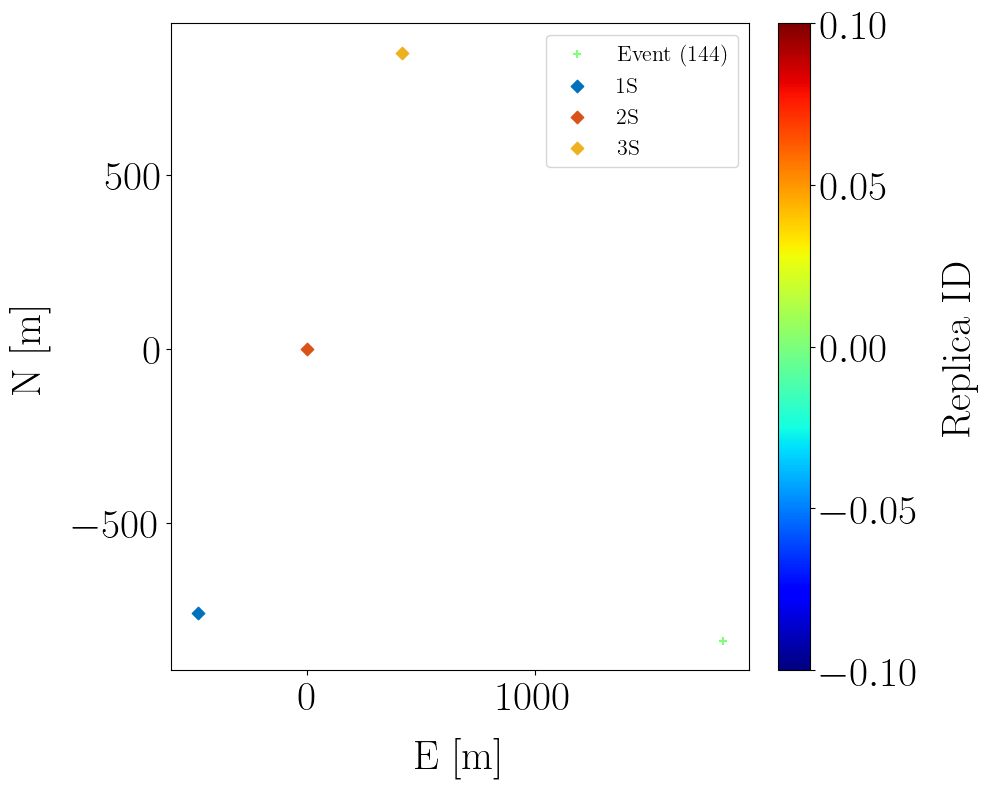

In [83]:
plot_seq_replica_positions(df_seq_selection, ds_gps, root_fig=None)

## Signal correspondant 

In [84]:
ds_sig_selection = ds_sig.sel(pulse_id=pulse_id_selected)
ds_sig_selection
# ds_sig

<xarray.Dataset> Size: 27MB
Dimensions:                     (h_index: 3, time: 1616182, t_ir: 10801,
                                 f_ir: 5401, f_rtf: 8193, f_csdm: 8193,
                                 h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 6MB 0.0 0.0005 ... 808.1 808.1
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * f_csdm                      (f_csdm) float32 33kB 0.0 0.1221 ... 999.9 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
    pulse_id                    int64 8B 400
Data variables:
    signal                      (h_index, time) float32 19MB ...
    arr_time_in_sec_from_start  (h_index) float32 12B ...
    ri_hat                      (h_index, t_ir) float32 130kB ...
    tf_hat_amp                  (h_index, f_ir) float32 65kB ...
    tf_hat_phase                (h_index, f_ir) float32 65kB ...
    rtf_amp_hat                 (h_index, f_rtf) float32 98kB ...
    rtf_phase_hat               (h_index, f_rtf) float32 98kB ...
    Rx                          (f_csdm, h_index, h_index_bis) float32 295kB ...
    Rv                          (f_csdm, h_index, h_index_bis) float32 295kB ...
    rtf_amp                     (h_index, f_ir) float32 65kB ...
    rtf_phase                   (h_index, f_ir) float32 65kB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        5.2005
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_11-44-26
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               2
    pulse_window_length_s:     10.04

In [85]:
df_seq_selection

,emission_datetime,sequence_id,src_pos_point,src_pos_status,deployed_length_m,hydrophone_distance_m,signal_type,frequency_min_hz,frequency_max_hz,duration_s,...,valid_detection_obs2,arrival_datetime_obs3,theoretical_propagation_time_obs3,measured_propagation_time_obs3,psnr_obs3,valid_detection_obs3,pulse_id,f_score_obs1,f_score_obs2,f_score_obs3
index,,,,,,,,,,,,,,,,,,,,,
1153,2025-10-16 11:44:30.987218750,144,,trailed,18,1.1,chirp,80.0,1000.0,5.0,...,True,2025-10-16 11:44:31.814,1.467387,0.826782,14.518401,True,400,0.73757,0.722752,0.750788


# Extraction de signaux d'intérêt pour le warping 

## Signal reçu 

### Aperçu du signal dans le domaine temps fréquence 

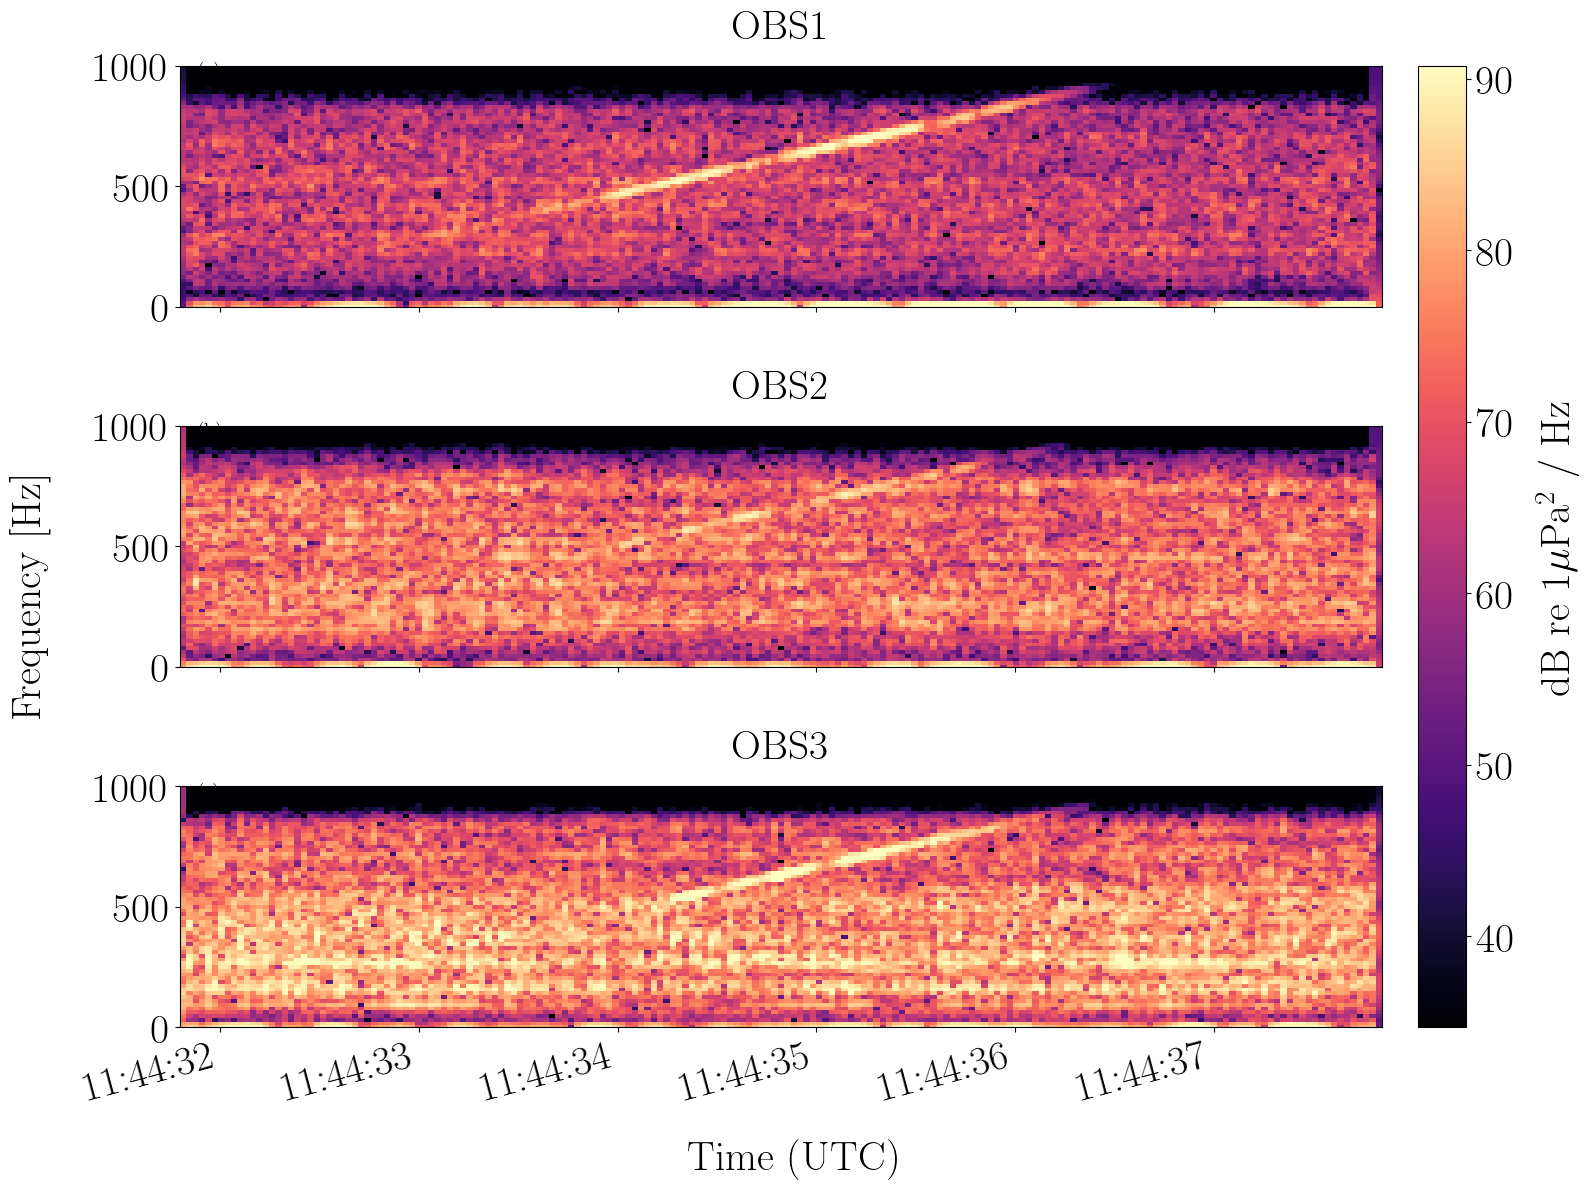

In [86]:
datetime_fmt = ds_sig.attrs["datetime_format"]
t_start = ds_sig.attrs[f"start_datetime"]

# tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.mean().item()

# sequence_start_dt = datetime.strptime(t_start, datetime_fmt) + timedelta(
#     seconds=int(np.floor(tarr_selected_pulse))
# )
# sequence_end_dt = sequence_start_dt + timedelta(
#     seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0]))
# )
sequence_start_dt = df_seq_selection["arrival_datetime_obs3"].iloc[0]
sequence_end_dt = sequence_start_dt + timedelta(
    seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0]))
)

# Add offset
# t_margin = (
#     df_seq_selection["repeat_period_s"].iloc[0] - df_seq_selection["duration_s"].iloc[0]
# )
t_margin = 1
sequence_start_dt -= timedelta(seconds=int(np.floor(t_margin * 0.5)))
sequence_end_dt += timedelta(seconds=int(np.ceil(t_margin * 0.5)))


plot_sequence_spectrogram(
    ds_wav,
    sequence_start_dt,
    sequence_end_dt,
    savefig=False,
    fig_folder=None,
    nperseg=2**7,
    noverlap=int(2**7 * 0.5),
    fmin=fmin,
    fmax=fmax,
    # fname="spectro_3obs",
)

ax = plt.gca()

# tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=2).item()
# sequence_start_dt = datetime.strptime(t_start, datetime_fmt) + timedelta(
#     seconds=int(np.floor(tarr_selected_pulse))
# )
# ax.axvline(sequence_start_dt)

### Signal temporel

On peut ensuite visualiser le signal dans le domaine temporel sur la fenêtre considérée 

Text(0.02, 0.5, 'Pressure [uPa]')

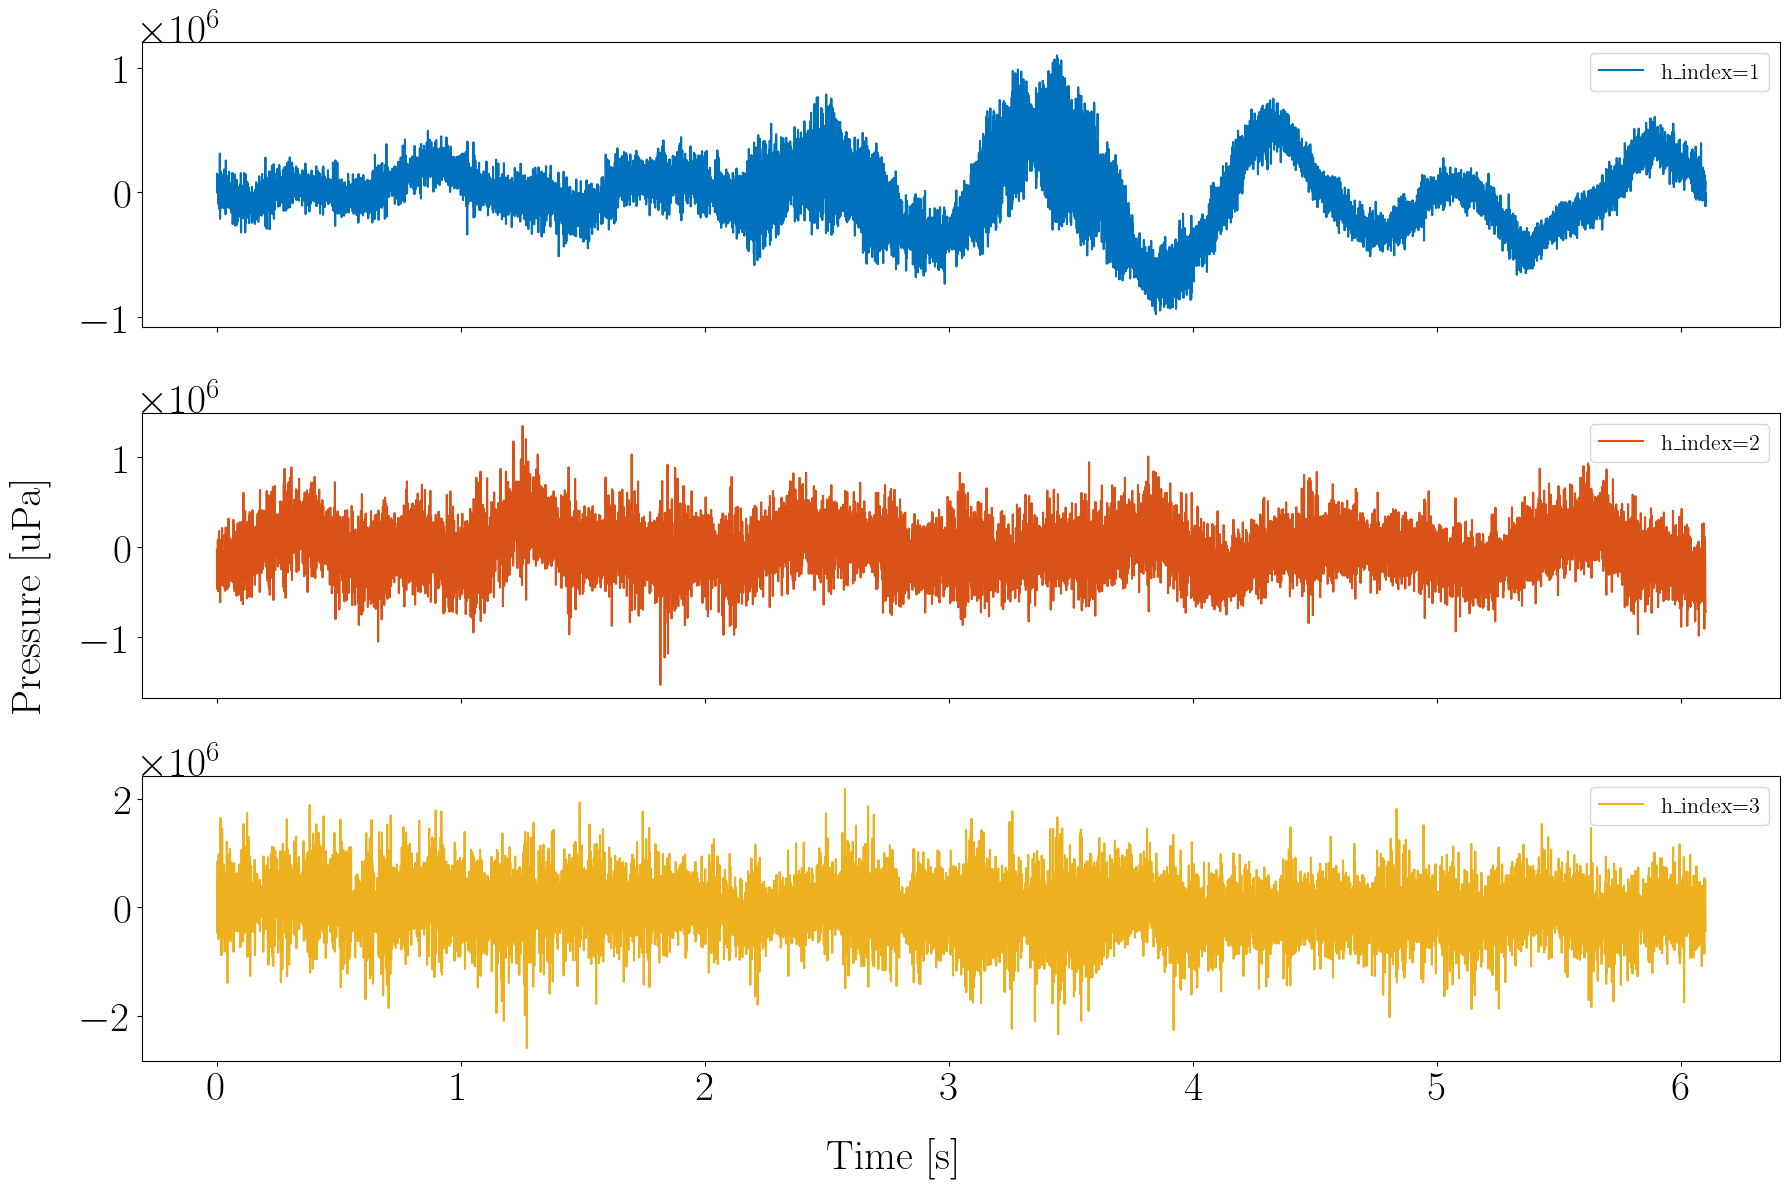

In [87]:
fig, axs = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
signals = []
# t_start_extract = []
# t_end_extract = []
for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    sequence_start_dt = df_seq_selection[f"arrival_datetime_obs{obs_id}"].iloc[0]
    sequence_end_dt = sequence_start_dt + timedelta(
        seconds=int(np.ceil(df_seq_selection["duration_s"].iloc[0])) + 1
    )

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (sequence_start_dt - t0).total_seconds() - 0.1
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (sequence_end_dt - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=obs_id).item()
    # dt_pulse_i = datetime.strptime(t_start, datetime_fmt) + timedelta(seconds=int(np.floor(tarr_selected_pulse)))
    # tau_pulse_i = (dt_pulse_i - sequence_start_dt).total_seconds()
    # print(tau_pulse_i)

    # t_start_extract.append(t_from_t0_start_s)
    # t_end_extract.append(t_from_t0_end_s)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})
    signals.append(sig_win.values)
    t = np.arange(len(sig_win)) / fs

    axs[i].plot(t, sig_win.values, label=f"h_index={obs_id}", color=color(i))
    axs[i].legend()

fig.supxlabel("Time [s]")
fig.supylabel("Pressure [uPa]")

### Filtrage et sauvegarde du signal filtré 

Le signal présente des oscillations à très basses fréquences. Pour se limiter au signal de la source on filtre dans la gamme du chirp : 80 - 1000 Hz

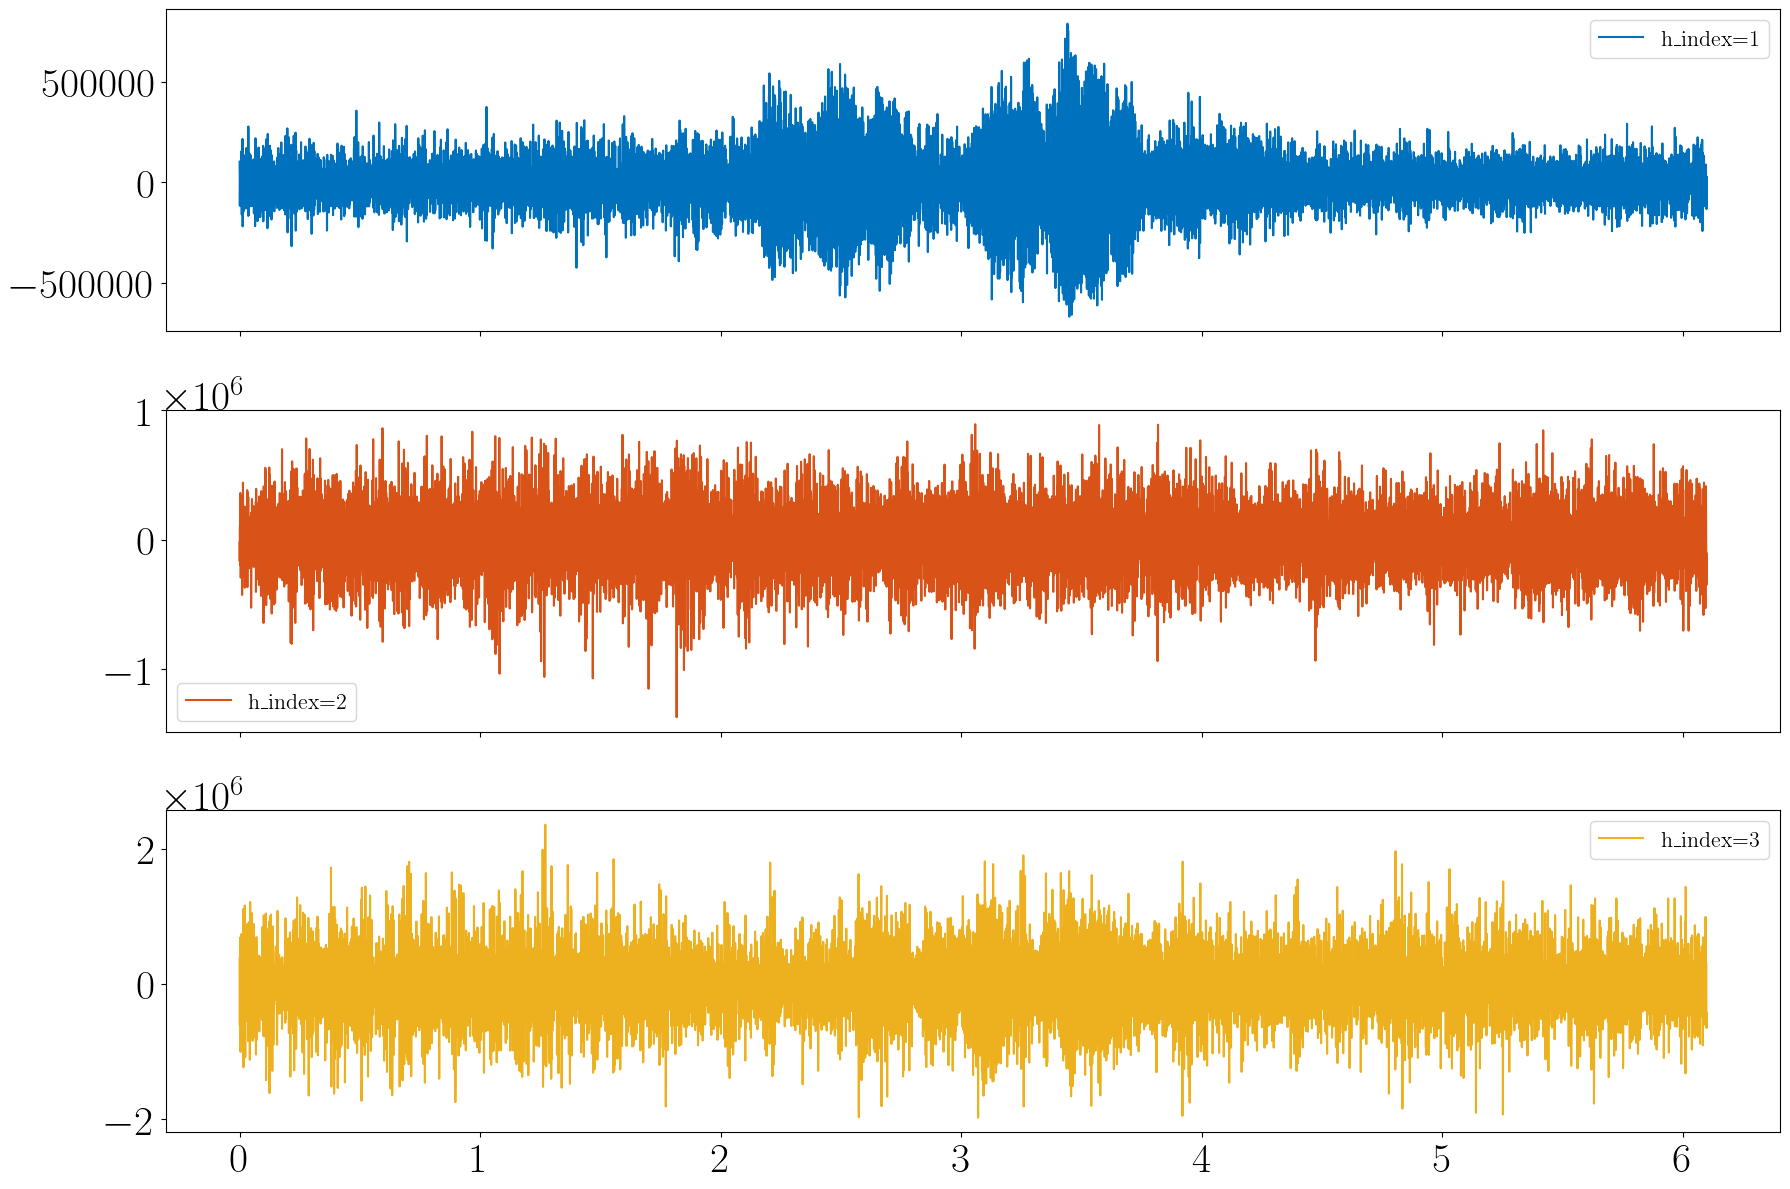

In [88]:
# root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\ressource\Bonnel_supp_publi_2020_warping\matlab_code\experimental_data\c_css_deconv\groix"
root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\extracted_signal_for_warping"

bf = BandFilter(order=4, lowcut=80, highcut=999)
fs = ds_sig_selection.fs

fig, axs = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    sig = signals[i]
    filtered_sig = bf.apply_filter(signal=sig, fs=fs)

    # tarr_selected_pulse = ds_sig_selection.arr_time_in_sec_from_start.sel(h_index=h_idx).item()
    # t_start = tarr_selected_pulse - 0.2
    # # t_start -= t_start_extract[i]
    # t_end = tarr_selected_pulse + df_seq_selection["duration_s"].iloc[0] + 0.5
    # print(t_start)

    # sig =
    axs[i].plot(t, filtered_sig, label=f"h_index={h_idx}", color=color(i))
    axs[i].legend()

    fpath = os.path.join(
        root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}.wav"
    )
    wavfile.write(
        fpath,
        fs,
        filtered_sig,
    )

## Signal source

8192


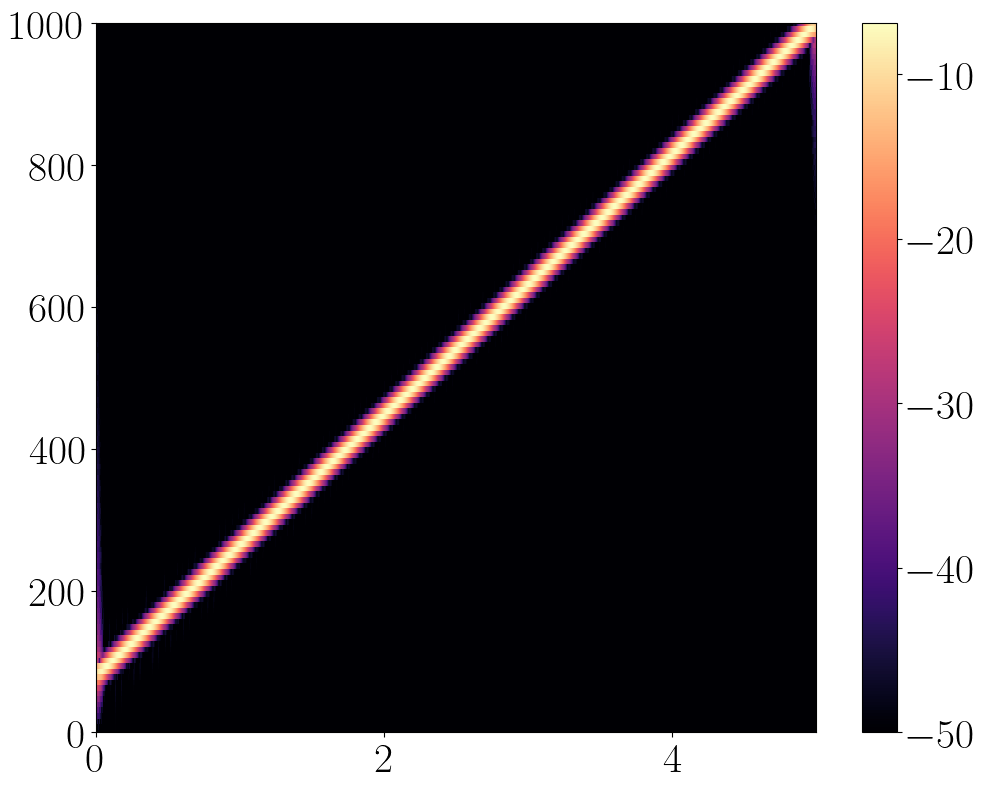

In [89]:
# Load source data
root_source_wav = os.path.join(root_groix_wav, "source")

# source_signal_fpath = os.apth.join(root_source_wav, "")
# fs_source, source_signal = wavfile.read(source_signal_fpath)

# With synthetic chirp
chirp_duration = df_seq["duration_s"].iloc[0]
# chirp_ns = chirp_duration /
f0 = 80
f1 = 1000
fs_source = 64000
t = np.arange(0, chirp_duration, 1 / fs_source)
x = sp.chirp(t, f0=f0, f1=f1, t1=chirp_duration, method="linear")

nperseg = 2**13
print(nperseg)
nw = 50
noverlap = nperseg - nw

(
    ff,
    tt,
    Sxx,
) = sp.stft(x, fs=fs_source, nperseg=nperseg, noverlap=noverlap, window="hamming")

plt.figure()
plt.pcolormesh(tt, ff, 20 * np.log10(np.abs(Sxx)), cmap="magma", vmin=-50)
plt.colorbar()
plt.ylim(0, f1)
plt.show()




In [90]:
# Save synthetic to wave file
fpath = os.path.join(root_wav_save, f"source_synthetic_chirp_{seq_id}.wav")
wavfile.write(
    fpath,
    fs_source,
    x,
)

# Déconvolution

Resampling (decimation) source signal from 64000 Hz to 2000 Hz


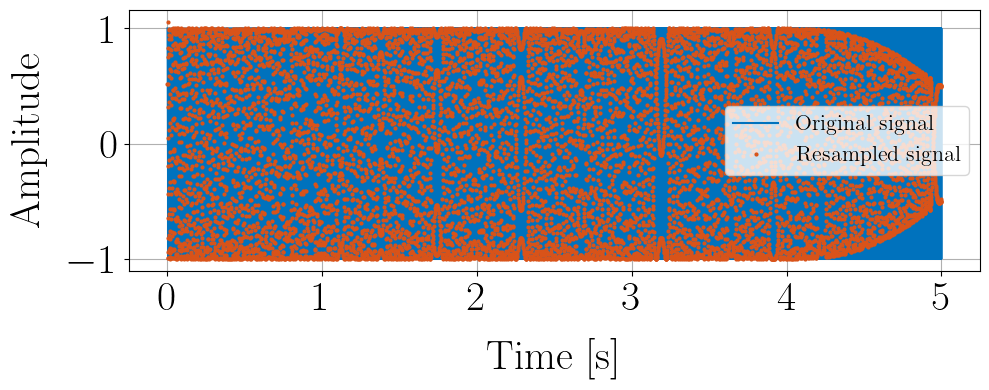

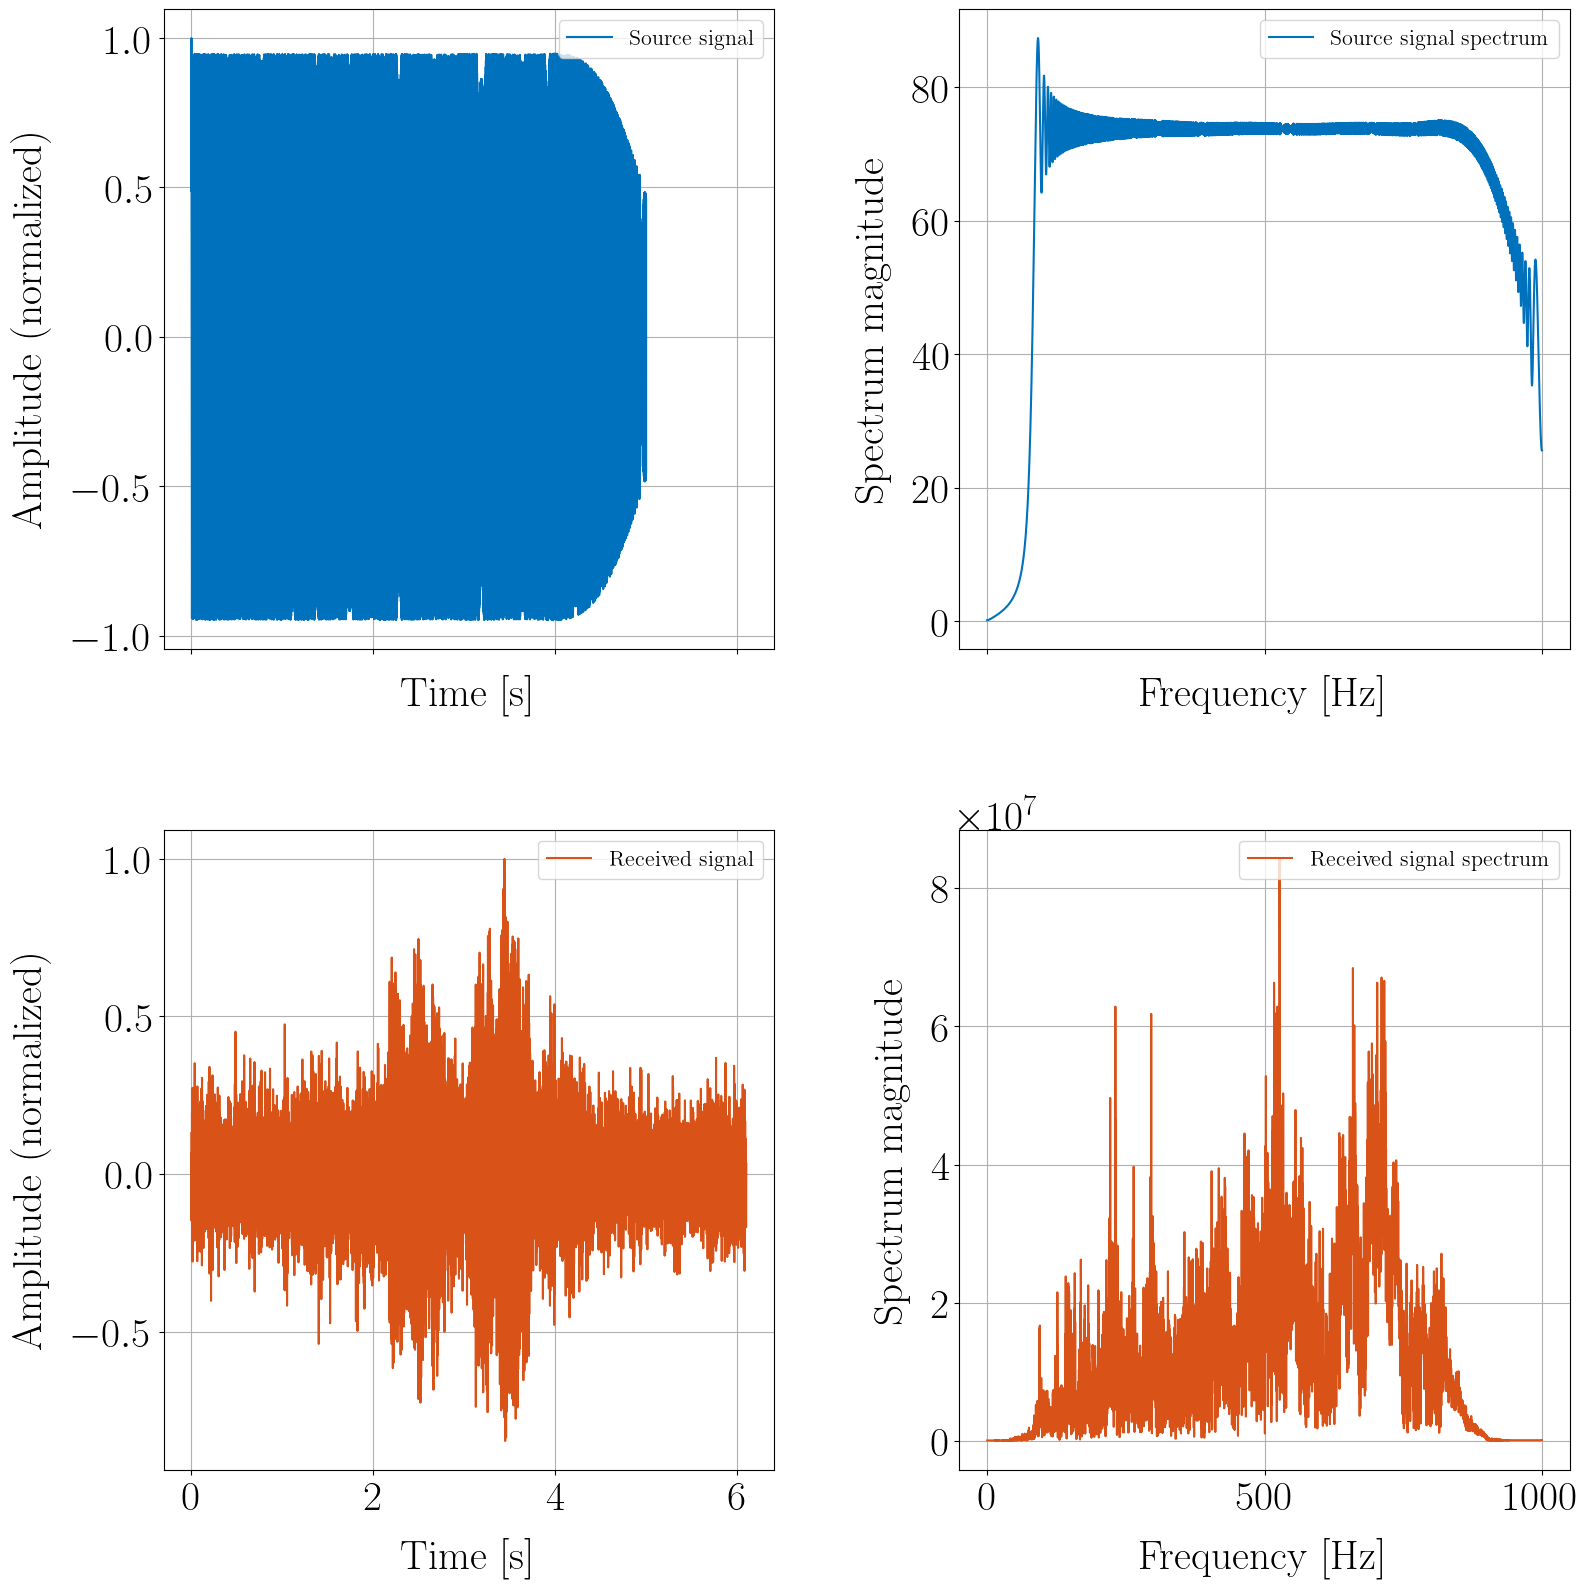

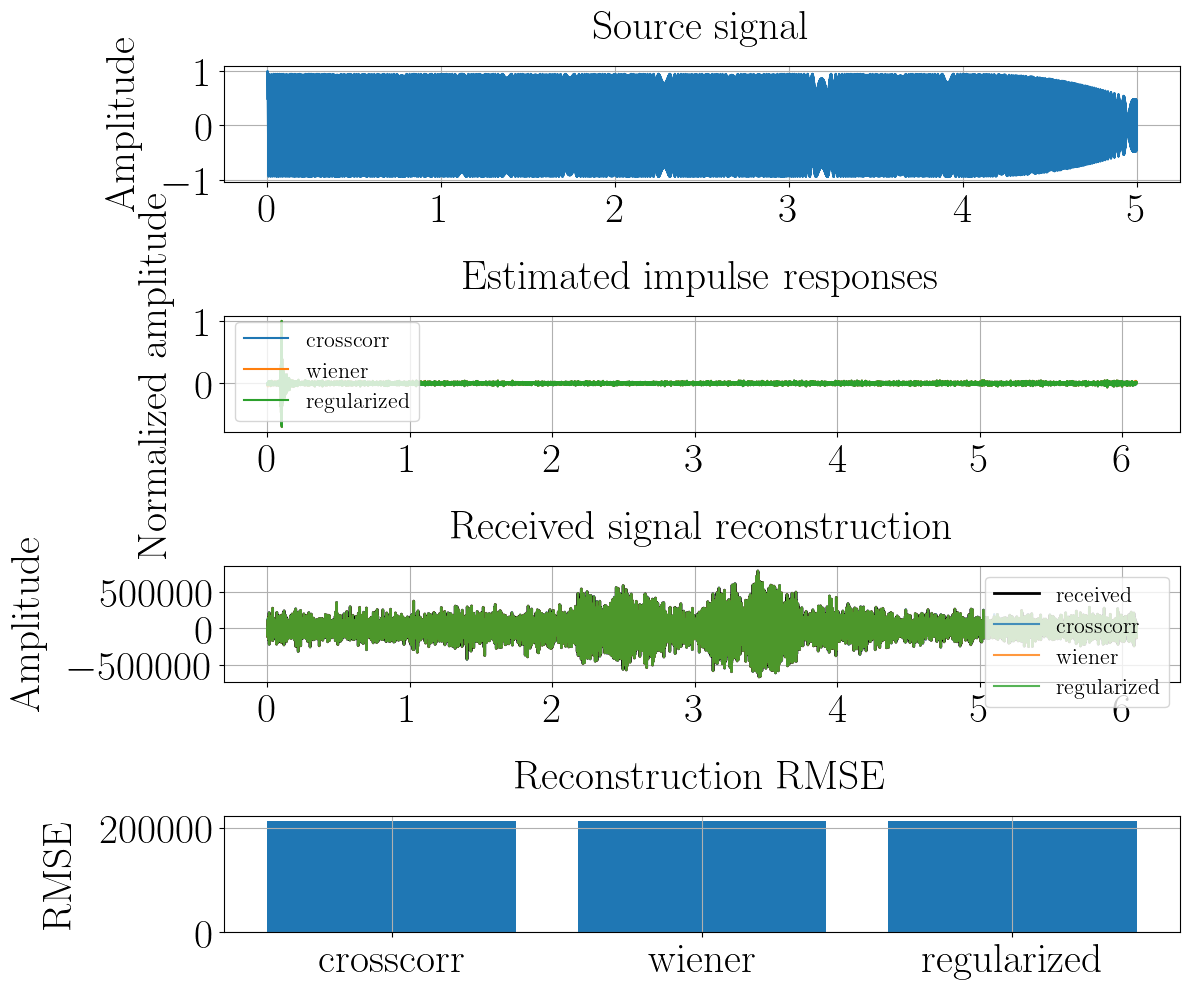


Reconstruction errors
--------------------------------------------------
wiener               RMSE = 9.821293e+01
regularized          RMSE = 3.129280e+02
crosscorr            RMSE = 2.942312e+03


In [91]:
from real_data_analysis.deconvolution_utils import test_css_deconvolution, plot_css_deconvolution_results

received_file = os.path.join(root_wav_save, f"OBS1_seq_{seq_id}_pulse_{pulse_id_selected}.wav")
source_file = os.path.join(root_wav_save, "source_synthetic_chirp_144.wav")

results = test_css_deconvolution(
    source_signal_fpath=source_file,
    received_signal_fpath=received_file,
)

plot_css_deconvolution_results(
    deconv_results=results, reference_deconv_fpath=None
)

Les meilleurs résultats sont obtenus pour le filtre de Wiener que l'on utilise donc dans la suite. 

In [49]:
# # Roll impulse response sa that it is in the middle of the window for better analysis
# t_shift = 0.1
# n_roll = int(t_shift * fs)

# fs_ir = results["fs"]
# ir = results["wiener"]
# t_ir = np.arange(len(ir)) / fs_ir

# rolled_ir = np.roll(ir, n_roll)

# plt.figure()
# plt.plot(t_ir, rolled_ir)
# plt.xlabel("Time [s]")
# plt.ylabel(r"$\hat{h(t)}$")
# plt.xlim(0, 0.5)

### Extraction des réponses pour les 3 capteurs 

On applique la démarche détaillée ci-dessus au trois capteurs et on sauvegarde les réponses impulsionnelles 

Resampling (decimation) source signal from 64000 Hz to 2000 Hz


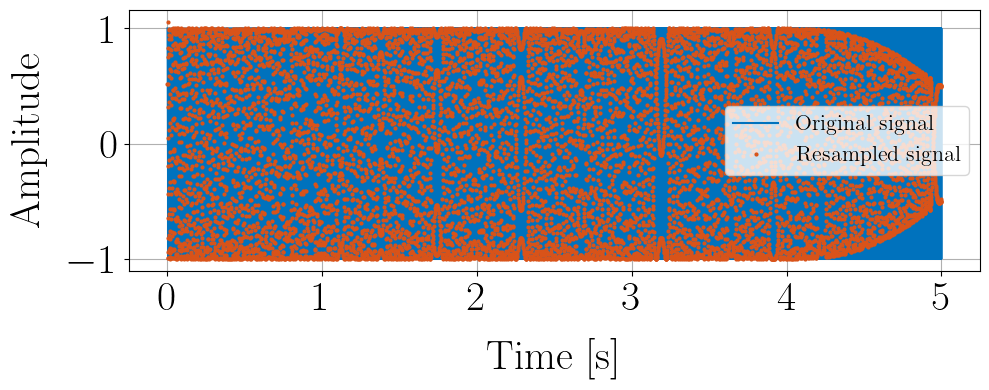

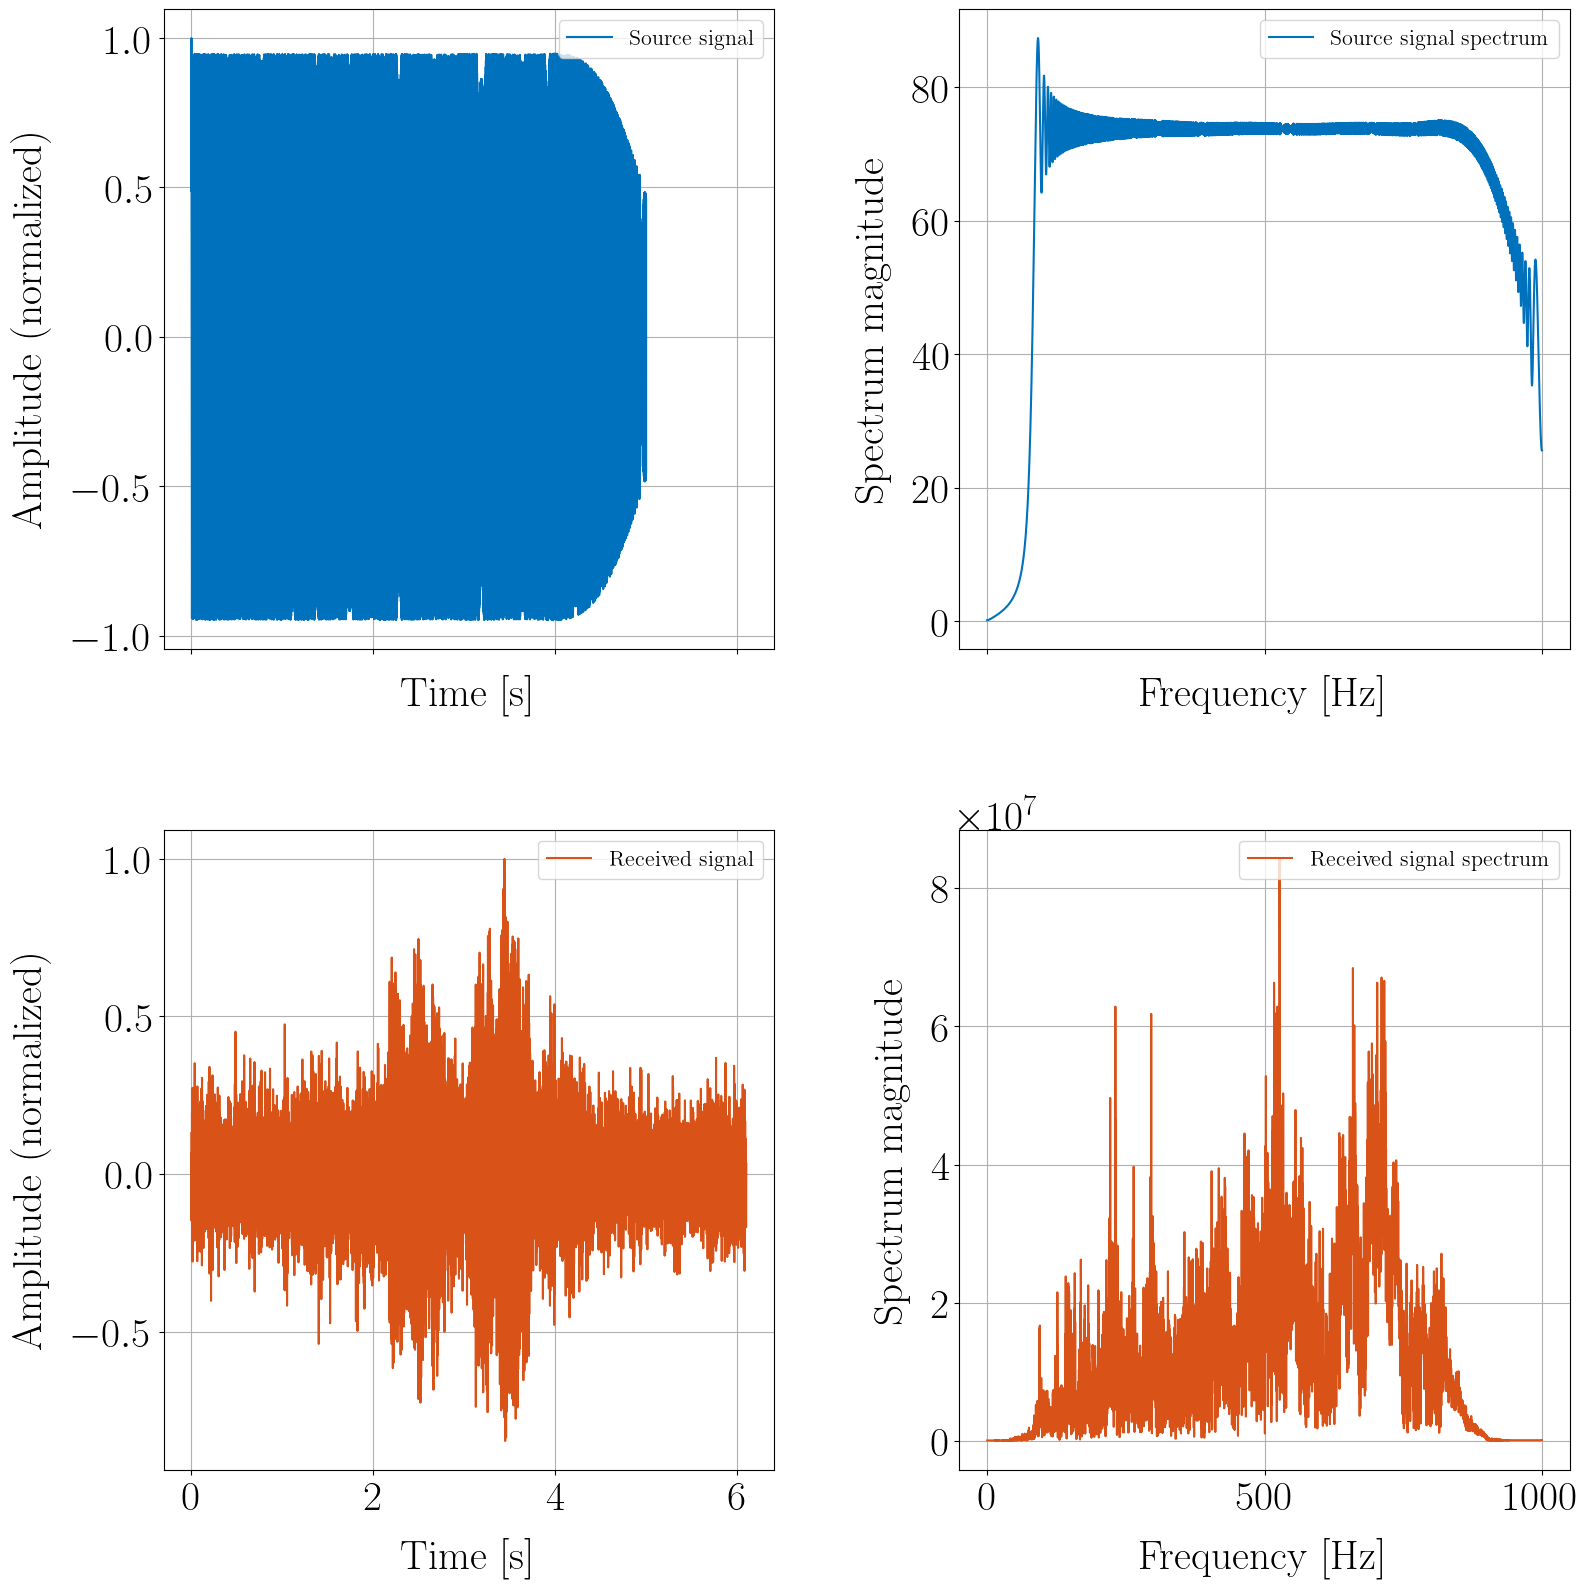

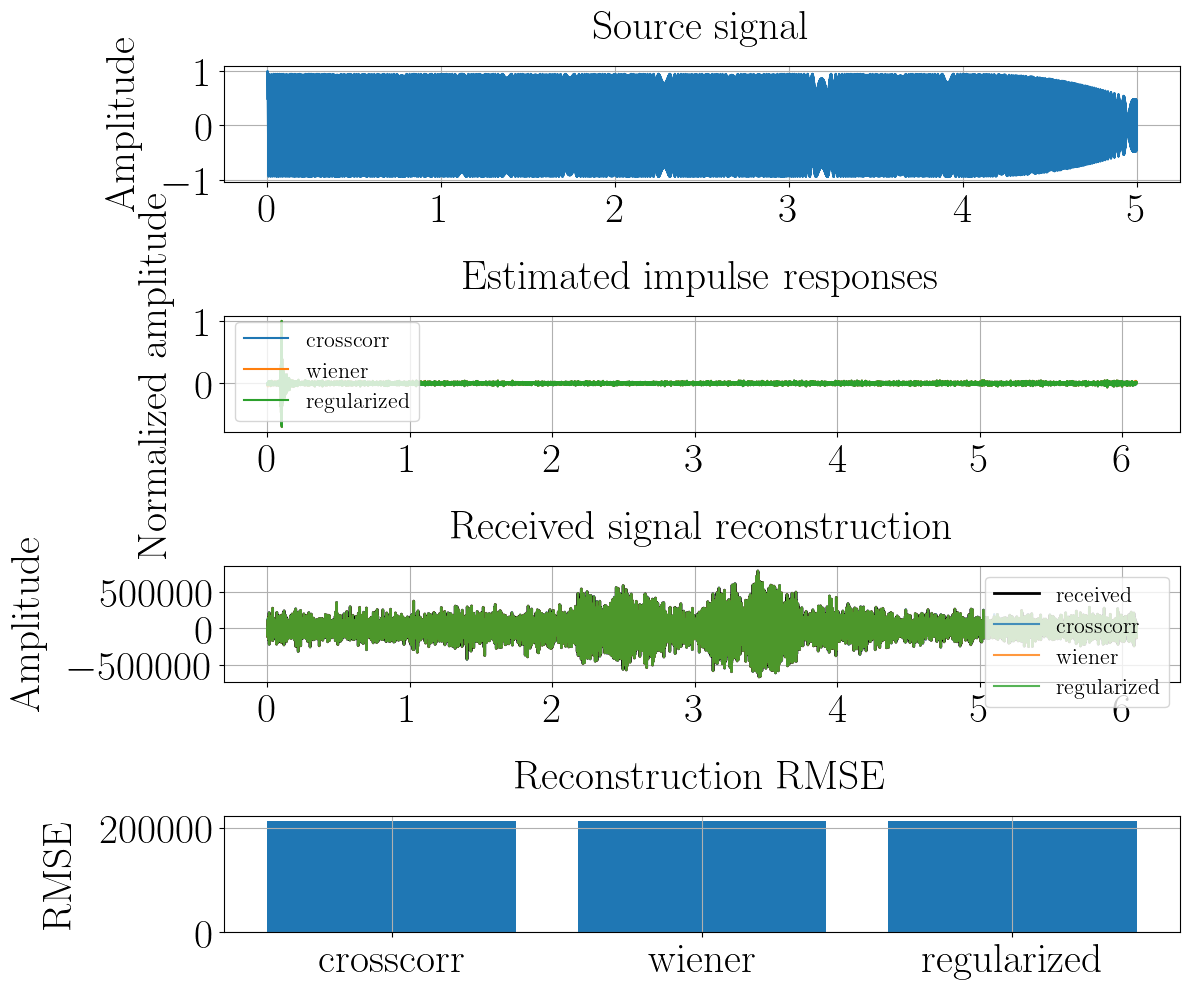


Reconstruction errors
--------------------------------------------------
wiener               RMSE = 9.821293e+01
regularized          RMSE = 3.129280e+02
crosscorr            RMSE = 2.942312e+03
Resampling (decimation) source signal from 64000 Hz to 2000 Hz


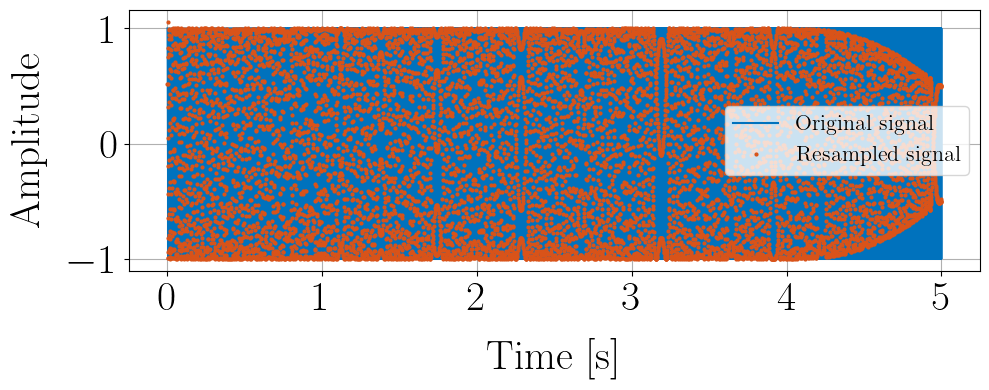

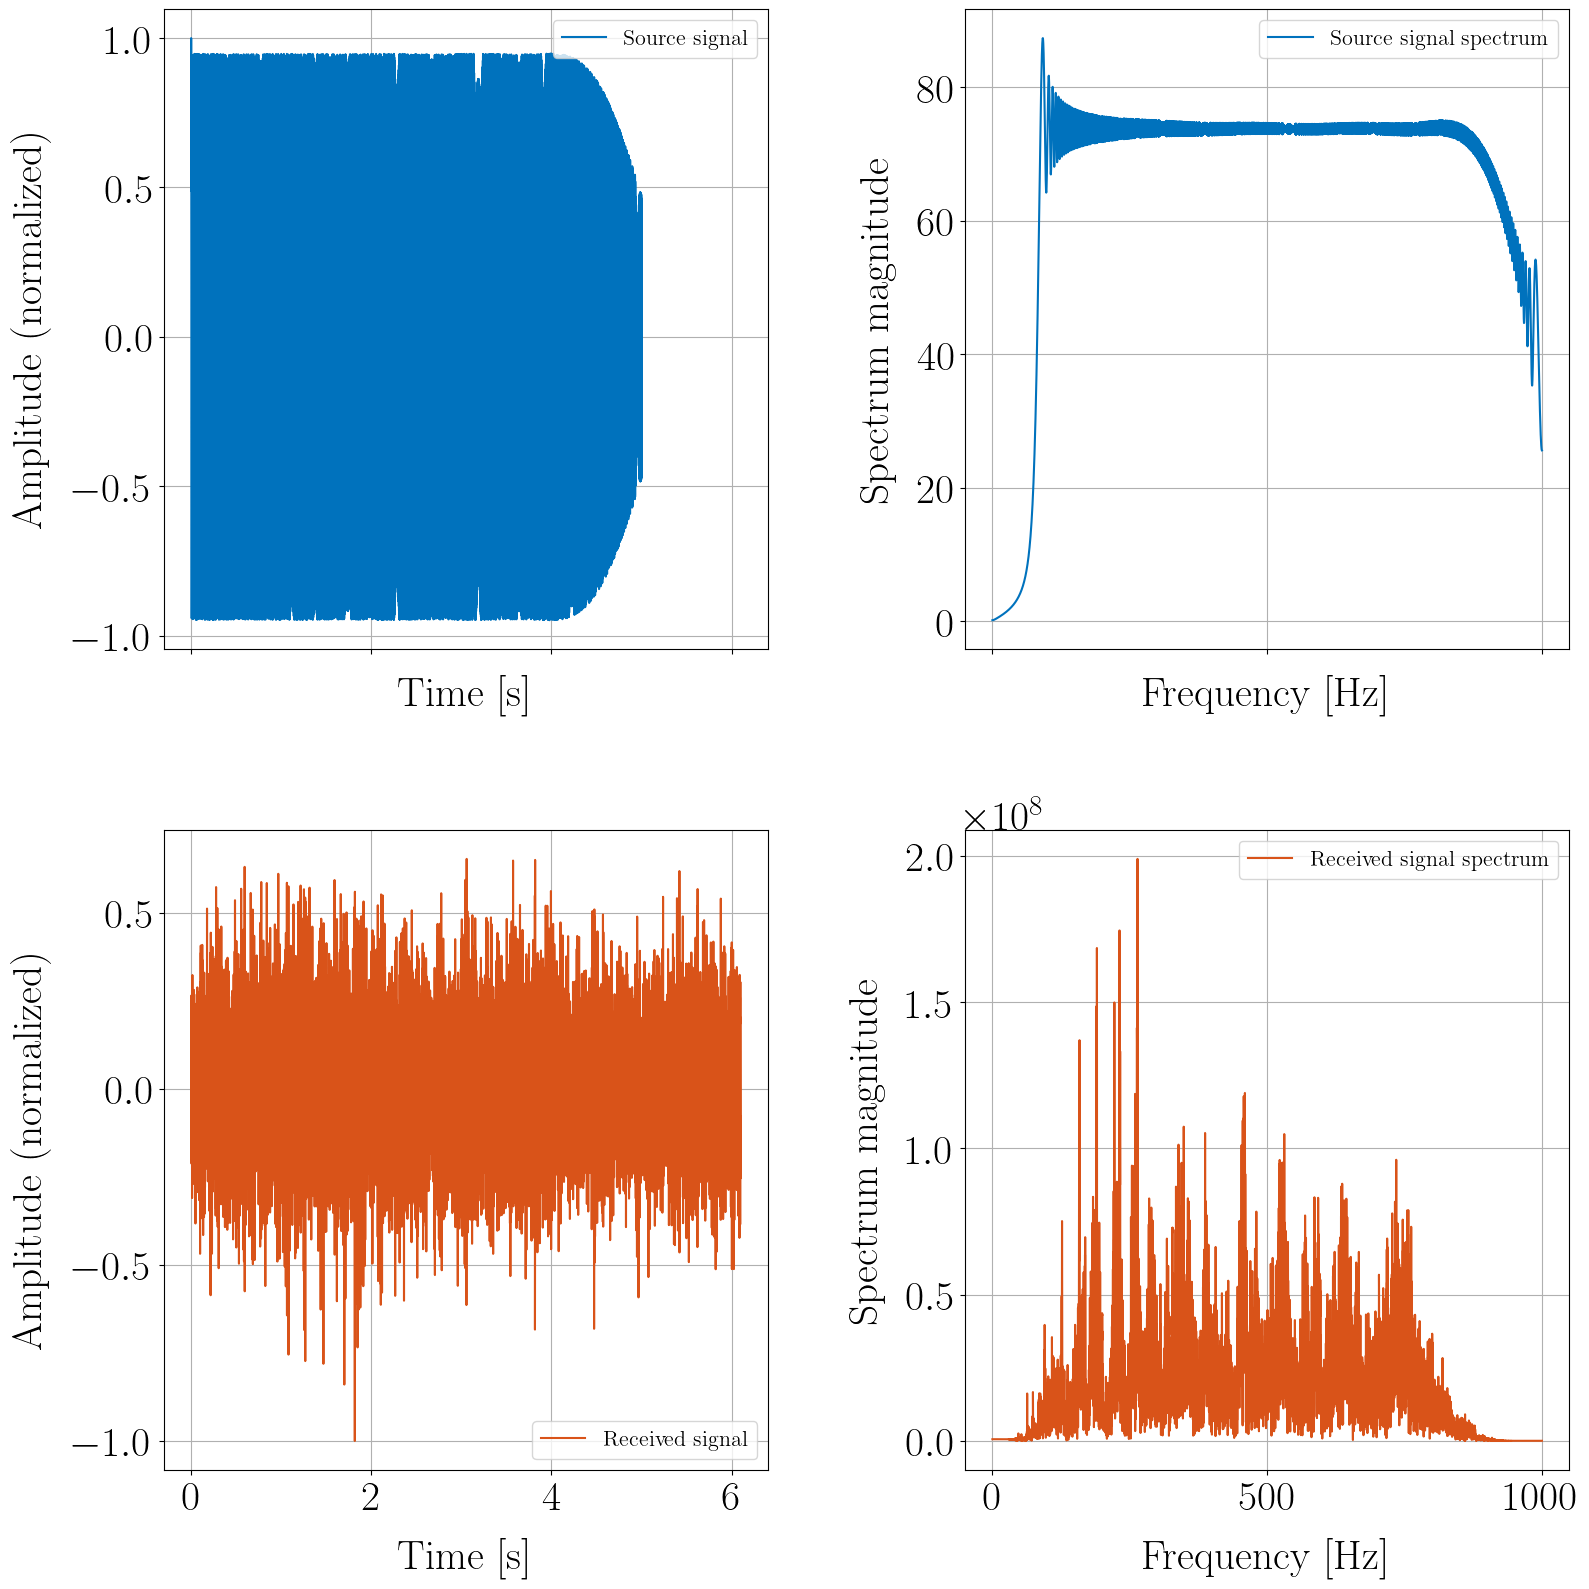

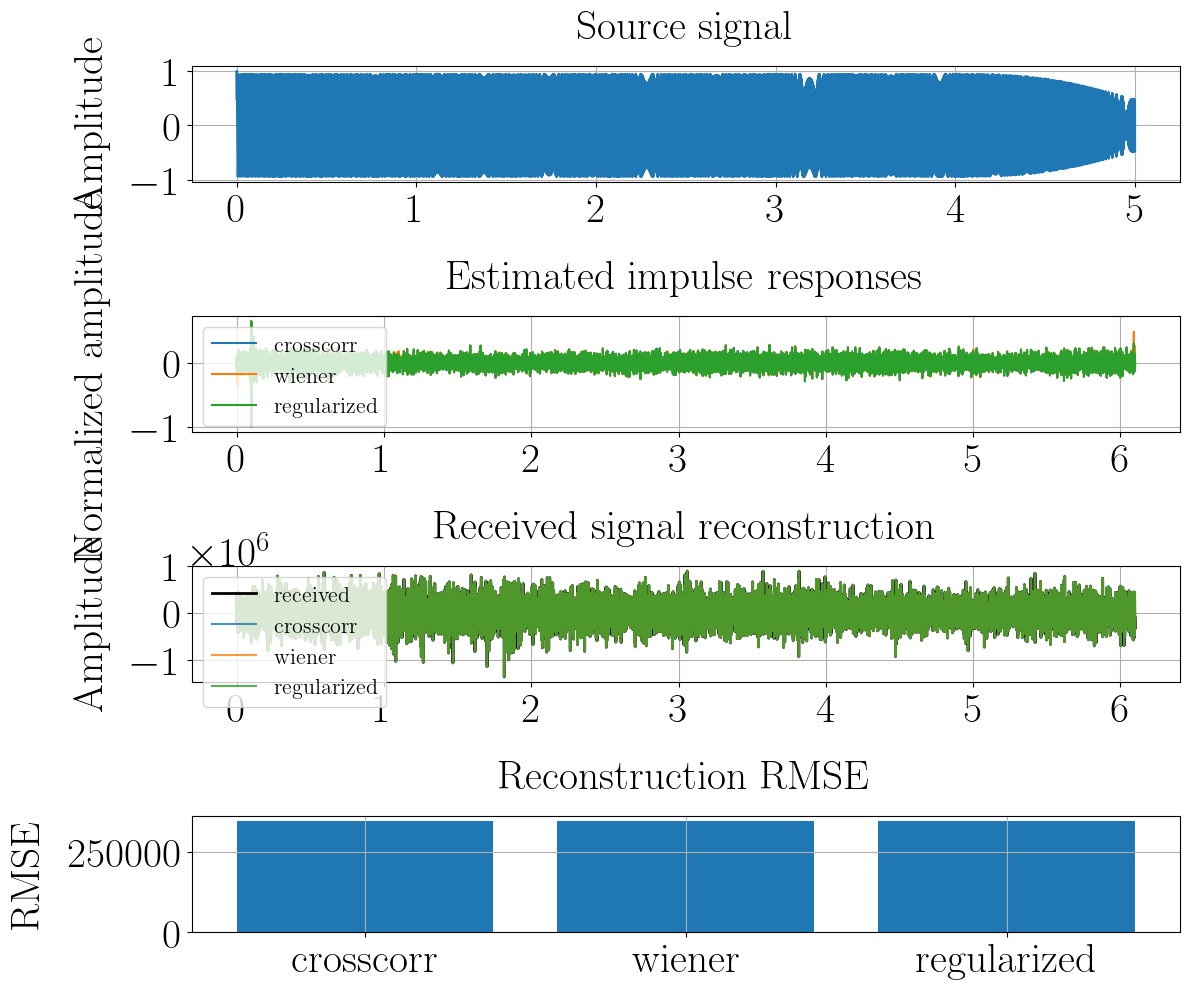


Reconstruction errors
--------------------------------------------------
wiener               RMSE = 6.669746e+02
regularized          RMSE = 1.367700e+03
crosscorr            RMSE = 8.752102e+03
Resampling (decimation) source signal from 64000 Hz to 2000 Hz


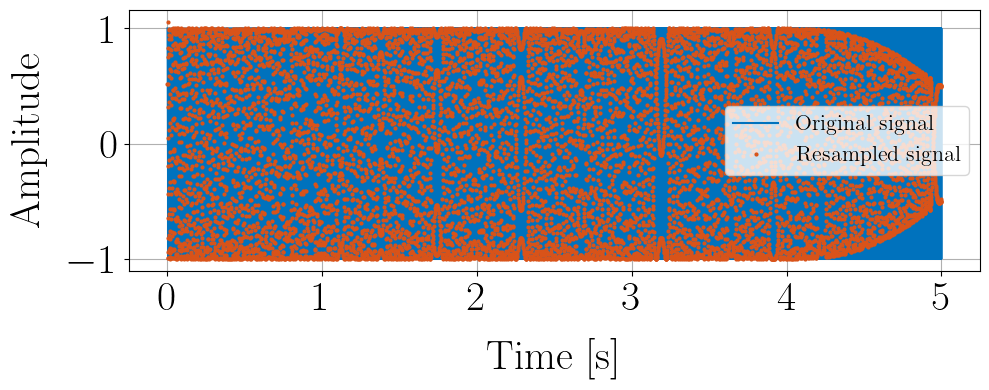

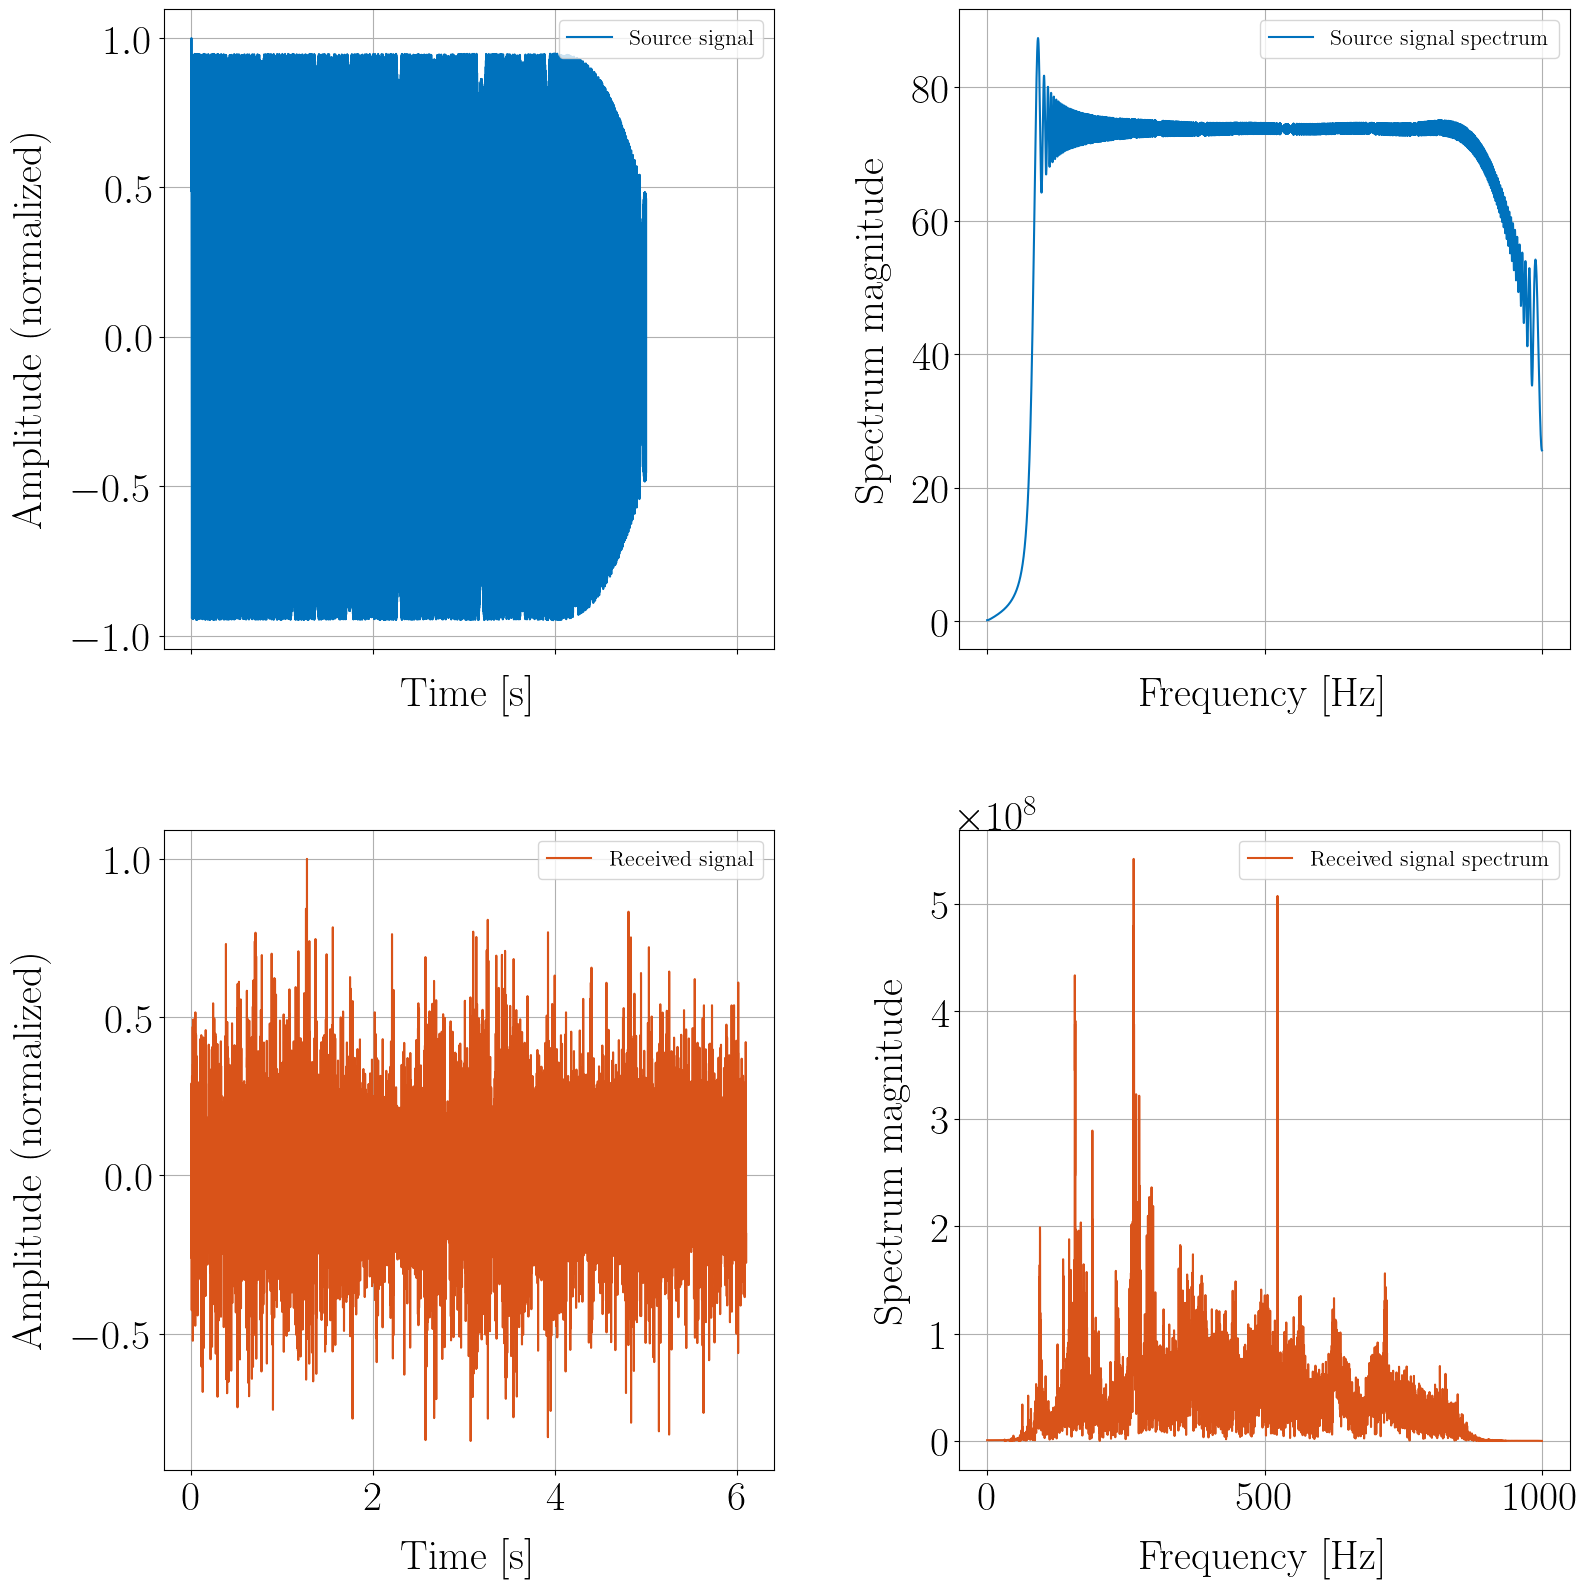

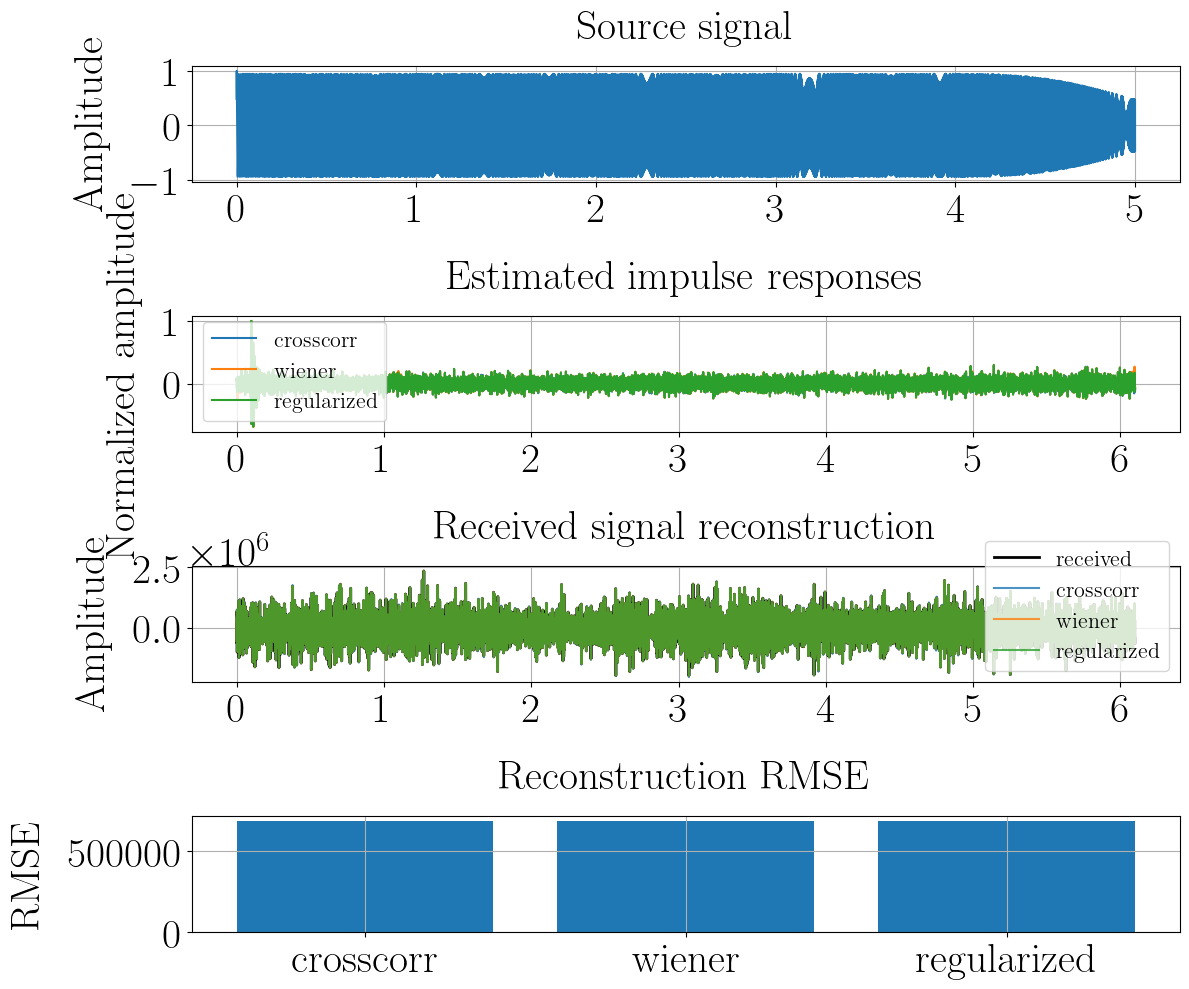


Reconstruction errors
--------------------------------------------------
wiener               RMSE = 8.241074e+02
regularized          RMSE = 2.128001e+03
crosscorr            RMSE = 2.197466e+04


In [100]:
source_file = os.path.join(root_wav_save, "source_synthetic_chirp_144.wav")

# t_shift = 0.00
# n_roll = int(t_shift * fs)

impulse_response = {f"OBS{obs_id}": None for obs_id in [1, 2, 3]}
for obs_id in [1, 2, 3]:
    received_file = os.path.join(root_wav_save, f"OBS{obs_id}_seq_{seq_id}_pulse_{pulse_id_selected}.wav")

    results = test_css_deconvolution(
        source_signal_fpath=source_file,
        received_signal_fpath=received_file,
    )

    plot_css_deconvolution_results(deconv_results=results, reference_deconv_fpath=None)

    ir = results["wiener"]
    impulse_response[f"OBS{obs_id}"] = ir

Text(0.02, 0.5, '$\\hat{h(t)}$')

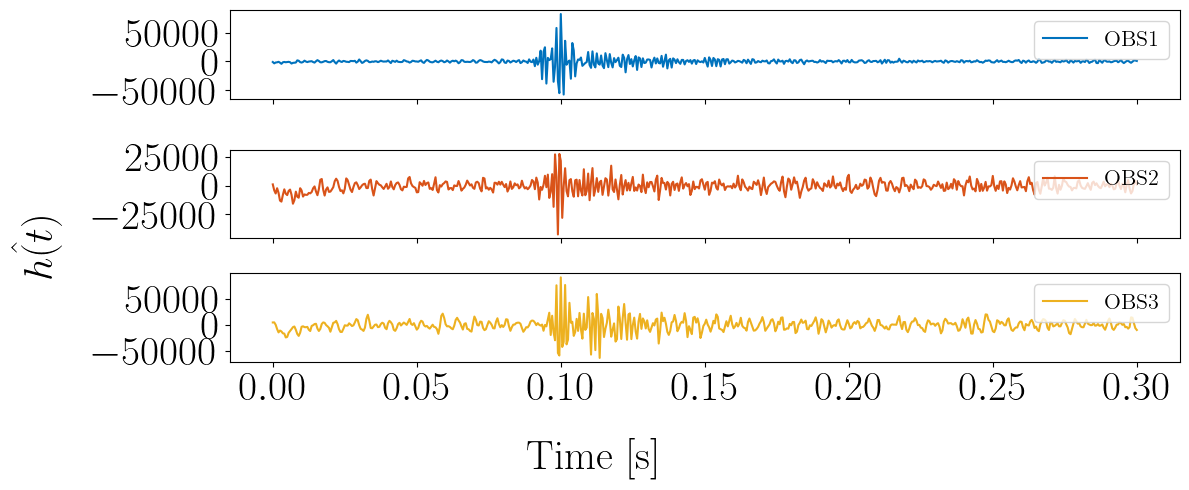

In [101]:
# Plot all and save
fs_ir = results["fs"]
t_ir = np.arange(len(impulse_response["OBS1"])) / fs_ir

# Limit to 1 sec of signal
t_win_idx = (t_ir <=0.3)
t_win = t_ir[t_win_idx]

fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    ir = impulse_response[f"OBS{h_idx}"][t_win_idx]
    axs[i].plot(t_win, ir, label=f"OBS{h_idx}", color=color(i))
    axs[i].legend(loc="upper right")

    fpath = os.path.join(
        root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}_deconv.wav"
    )
    wavfile.write(
        fpath,
        fs_ir,
        ir,
    )

fig.supxlabel("Time [s]")
fig.supylabel(r"$\hat{h(t)}$")

In [96]:
impulse_response

{'OBS1': array([ -995.75377883, -3323.03983107, -1854.92136097, ...,
         -875.24140311,  -284.24911434,  1391.0670662 ], shape=(12200,)),
 'OBS2': array([ 1107.71999313, -4066.42308593, -6834.86222508, ...,
         4795.31543792,  1017.62145062, -3460.15689026], shape=(12200,)),
 'OBS3': array([ 4592.99416577,  4746.08858342,   194.17180607, ...,
         7574.13806723, -7946.58898512, -6116.99504574], shape=(12200,))}

Text(0.02, 0.5, 'Frequency [Hz]')

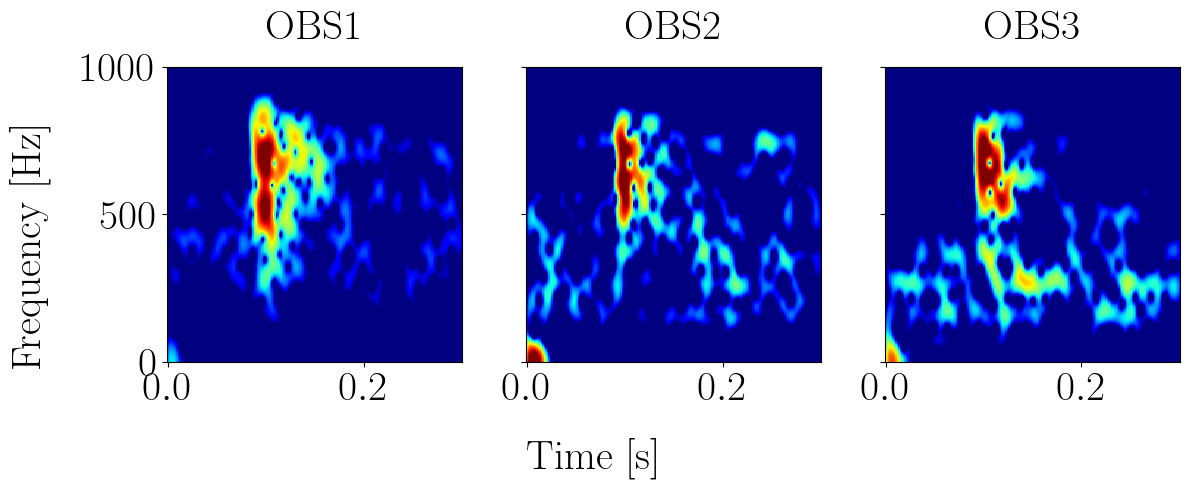

In [102]:
nperseg = 51
nfft = 2024
noverlap = int(nperseg * 0.95)

fig, axs = plt.subplots(1, 3, figsize=(12, 5), sharey=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    ir = impulse_response[f"OBS{h_idx}"][t_win_idx]
    # axs[i].plot(t_win, ir, label=f"OBS{h_idx}", color=color(i))

    f, t, Sxx = sp.stft(
        ir,
        fs=fs_ir,
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        scaling="psd",  
    )
    Sxx_db= 20*np.log10(abs(Sxx))

    axs[i].pcolormesh(
        t,
        f,
        20*np.log10(abs(Sxx)),
        cmap="jet",
        vmin=np.percentile(Sxx_db, 70),
        vmax=np.percentile(Sxx_db, 99.5),
    )
    axs[i].set_title(f"OBS{h_idx}")

fig.supxlabel("Time [s]")
fig.supylabel("Frequency [Hz]")

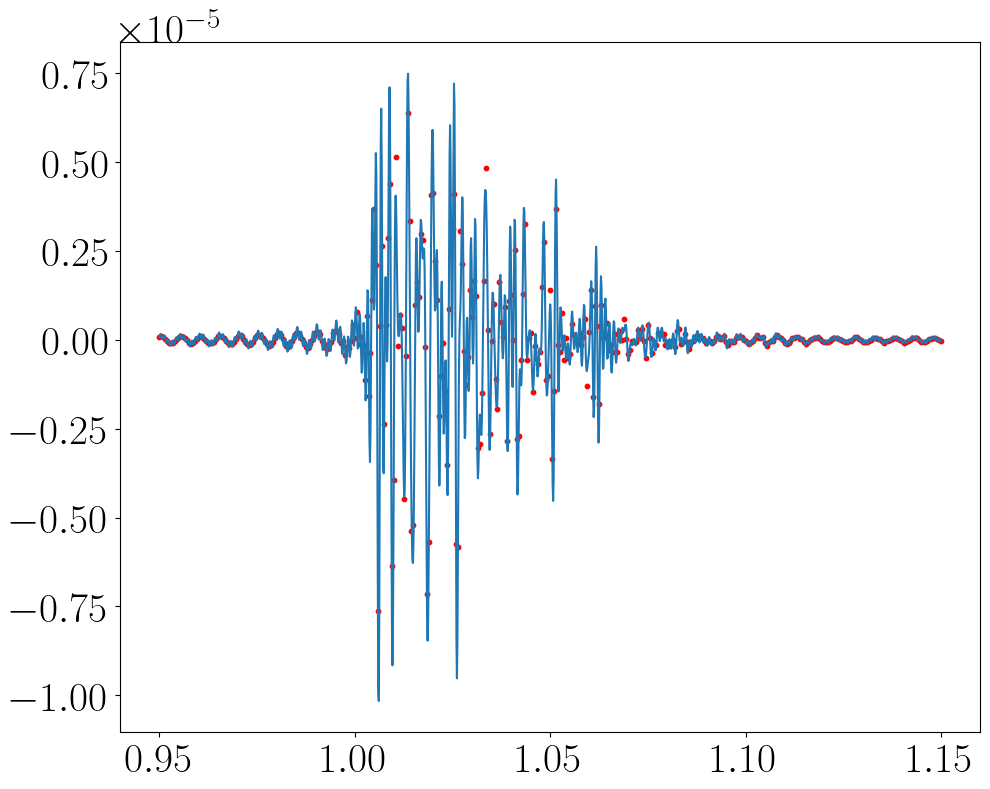

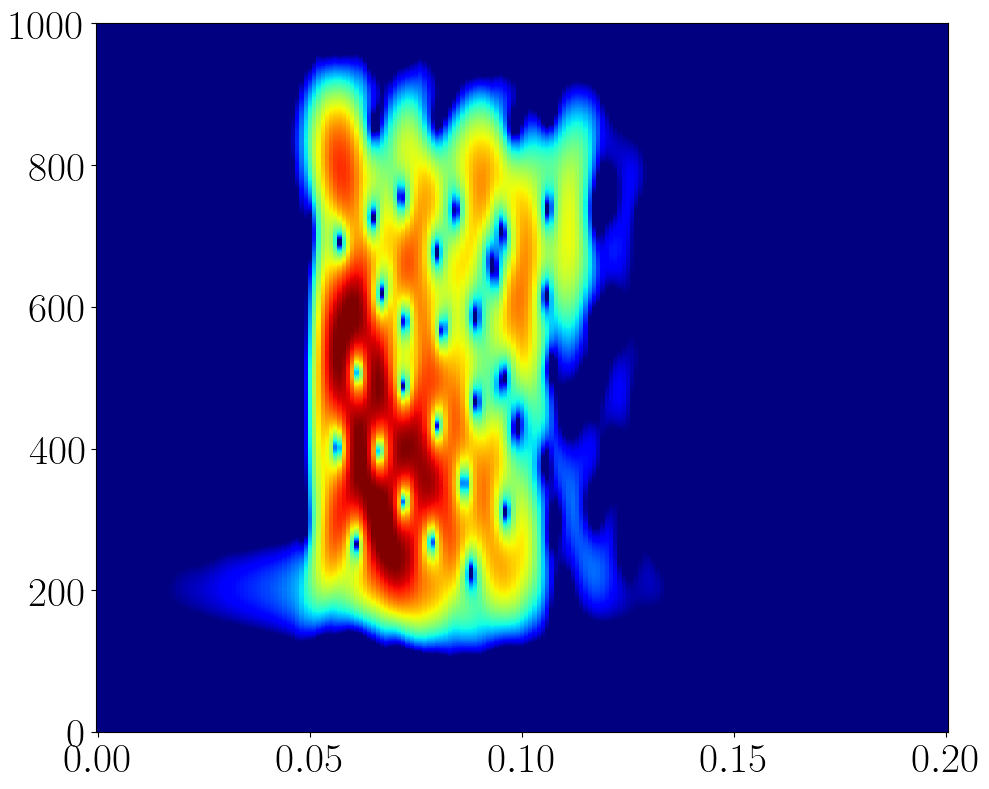

In [120]:
# Plot all and save
fs_kraken, kraken_ir = wavfile.read(os.path.join(root_wav_save, "kraken_ir.wav"))
# fs_ir = results["fs"]
t_krak = np.arange(len(kraken_ir)) / fs_kraken

# Limit signal
t_win_idx = (t_krak <= 1.15) & (t_krak >= 0.95)
t_win = t_krak[t_win_idx]
kraken_win = kraken_ir[t_win_idx]
# Decimate to 1000 Hz for better visualization
kraken_win_decimated = sp.decimate(kraken_win, 4)


plt.figure()
plt.plot(t_win, kraken_win)

t_win_decimated = t_win[::4]
fs_kraken_decimated = fs_kraken / 4
plt.scatter(t_win_decimated, kraken_win_decimated, color="red", s=10)


nperseg = 31
nfft = 2024
noverlap = int(nperseg * 0.95)

f, t, Sxx = sp.stft(
    kraken_win_decimated,
    fs=fs_kraken_decimated,
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    scaling="psd",
)

# f, t, Sxx = sp.stft(
#     kraken_win,
#     fs=fs_kraken,
#     nperseg=nperseg,
#     noverlap=noverlap,
#     nfft=nfft,
#     scaling="psd",
# )
Sxx_db= 20*np.log10(abs(Sxx))

plt.figure()
plt.pcolormesh(
    t,
    f,
    20*np.log10(abs(Sxx)),
    cmap="jet",
    vmin=np.percentile(Sxx_db, 70),
    vmax=np.percentile(Sxx_db, 99.5),
)

In [112]:
fs_kraken

8000

In [54]:
from propa.ideal_waveguide import (
    kr,
    psi,
    psi_normalised,
    h,
    field,
    plot_tl,
    nb_propagating_modes,
    intensity,
    intensity_1,
)

# n_propagating_modes_f0 = nb_propagating_modes(
#     f=100, c=1500, depth=30, bottom_bc="prefectly_rigid"
# )
# print(f"Number of propagating modes: {n_propagating_modes_f0}")
f0 = 100
depth = 30
k = 2 * np.pi * f0 / 1500
n = k * depth / np.pi + 1 / 2
print(n)

4.500000000000001


# Left overs : analyse des RI estimée 

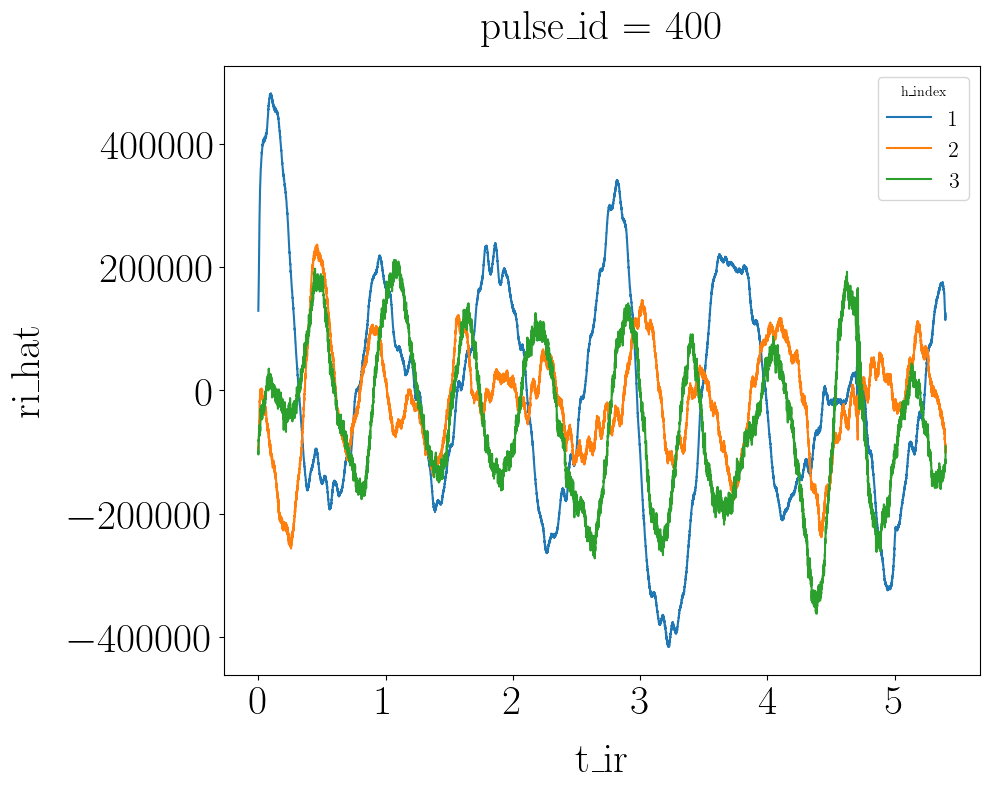

In [55]:
ds_sig_selection.ri_hat.plot(x="t_ir", hue="h_index")

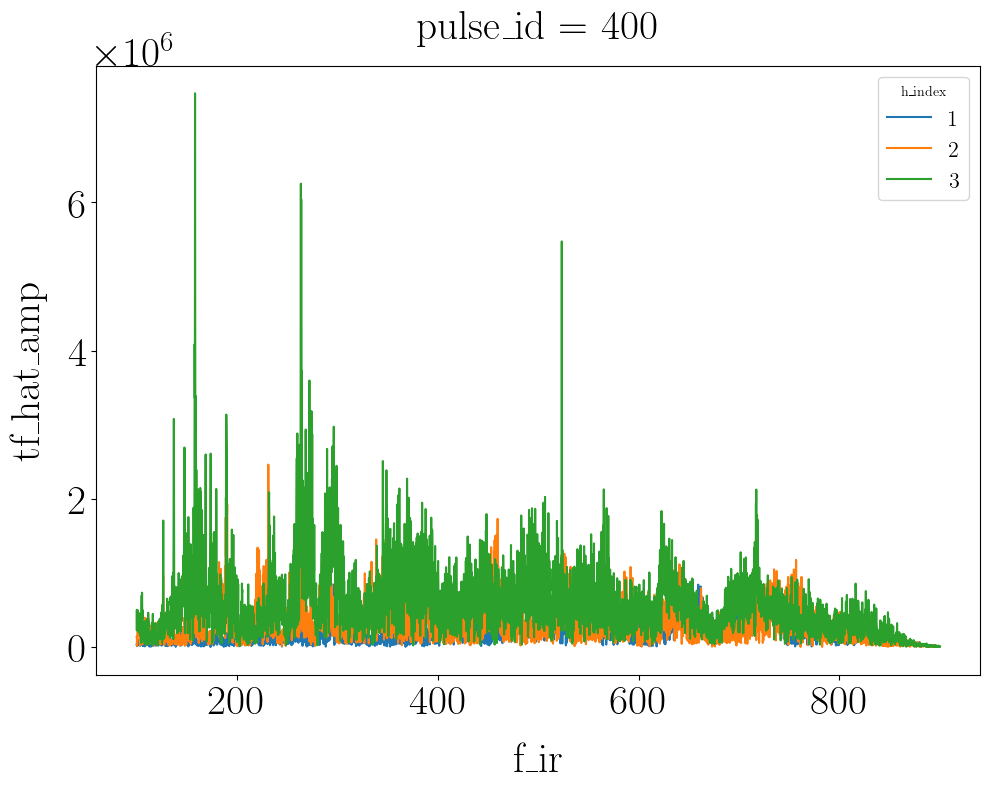

In [56]:
# ds_sig_selection.tf_hat_amp
ds_sig_selection.tf_hat_amp.sel(f_ir=slice(100, 900)).plot(x="f_ir", hue="h_index")
# ds_sig_selection

En dessous de la fréquence fmin = 80 Hz du chirp la déconvolution n'a pas de sens. Ceci conduit à des composantes basses fréquences erronées. Pour remonter à la vrai réponse impulsionnelle il faut filtrer dans la bande du signal. Ici on filtre dans la bande 100, 900 Hz pour tenir compte de la réponse de la source et de la réponse du récepteur.  

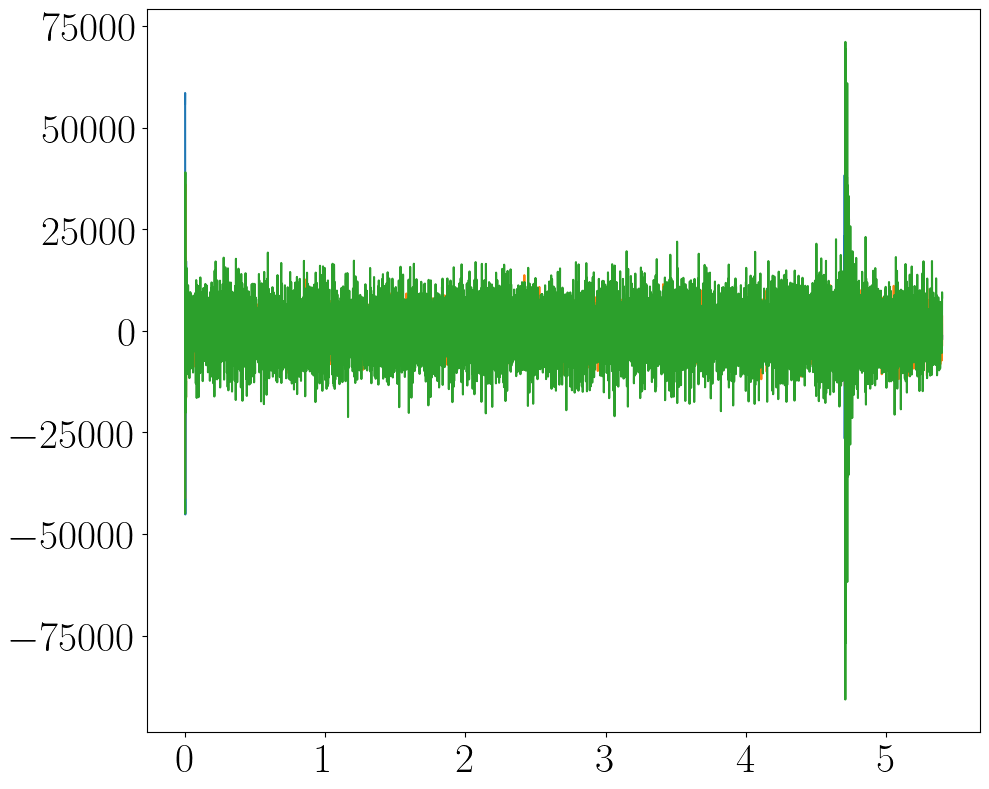

In [57]:
bf = BandFilter(order=4, lowcut=100, highcut=900)


fs = ds_sig_selection.fs

plt.figure()
impulse_responses = []
for h_idx in ds_sig_selection.h_index.values:
    ir_idx = ds_sig_selection.ri_hat.sel(h_index=h_idx).values
    filtered_ir = bf.apply_filter(signal=ir_idx, fs=fs)
    impulse_responses.append(filtered_ir)
    plt.plot(ds_sig_selection.t_ir, filtered_ir, label=f"h_index={h_idx}")

Il reste à présent à appliquer un déphasage (ou a roll) pour afficher en fonction t - r/c. En pratique trouver le bon déphasage n'est a priori pas évident, cela dépend de la fenêtre que l'on a initallement considéré pour la déconvolution. Ici on peut se contenter de tâtonner pour centrer les signaux et éviter le wrap temporel 

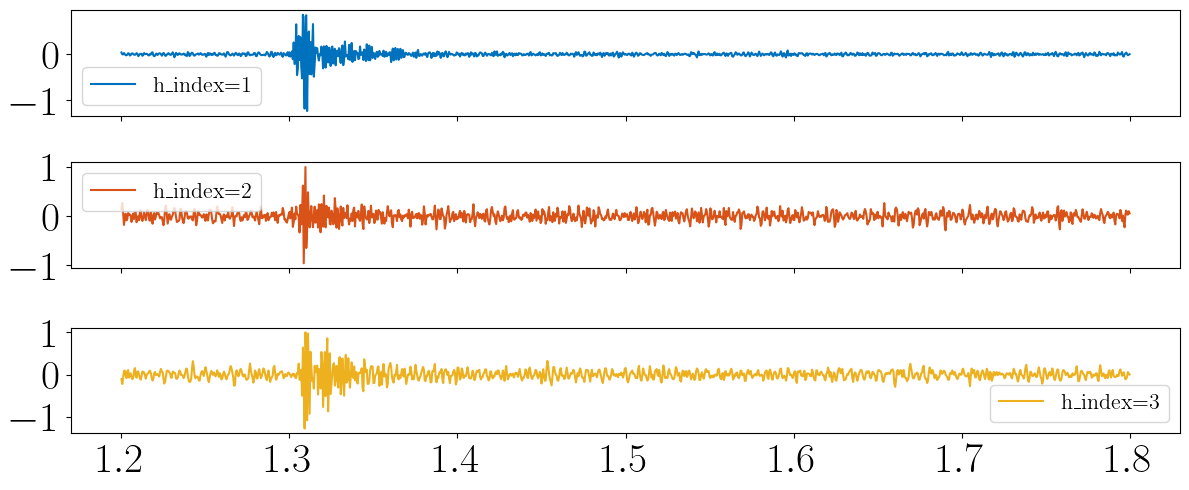

In [58]:
t_shift = 2
n_roll = int(t_shift * fs)

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 1.8)
t_win = t_ir[t_win_idx]

fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True)
for i, h_idx in enumerate(ds_sig_selection.h_index.values):
    rolled_ir = impulse_responses[i] / impulse_responses[i].max()
    rolled_ir = np.roll(rolled_ir, n_roll)
    rolled_ir = rolled_ir[t_win_idx]

    axs[i].plot(t_win, rolled_ir, label=f"h_index={h_idx}", color=color(i))
    axs[i].legend()

    fpath = os.path.join(
        root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}_deconv.wav"
    )
    wavfile.write(
        fpath,
        fs,
        rolled_ir,
    )


nperseg = 256, noverlap=243


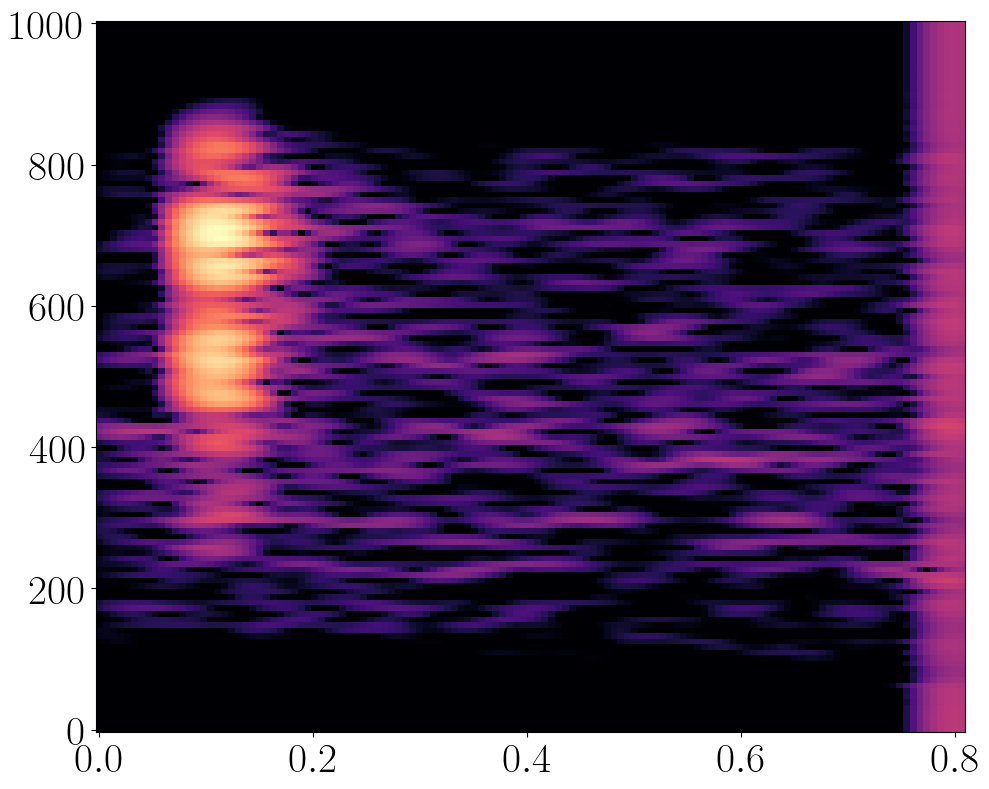

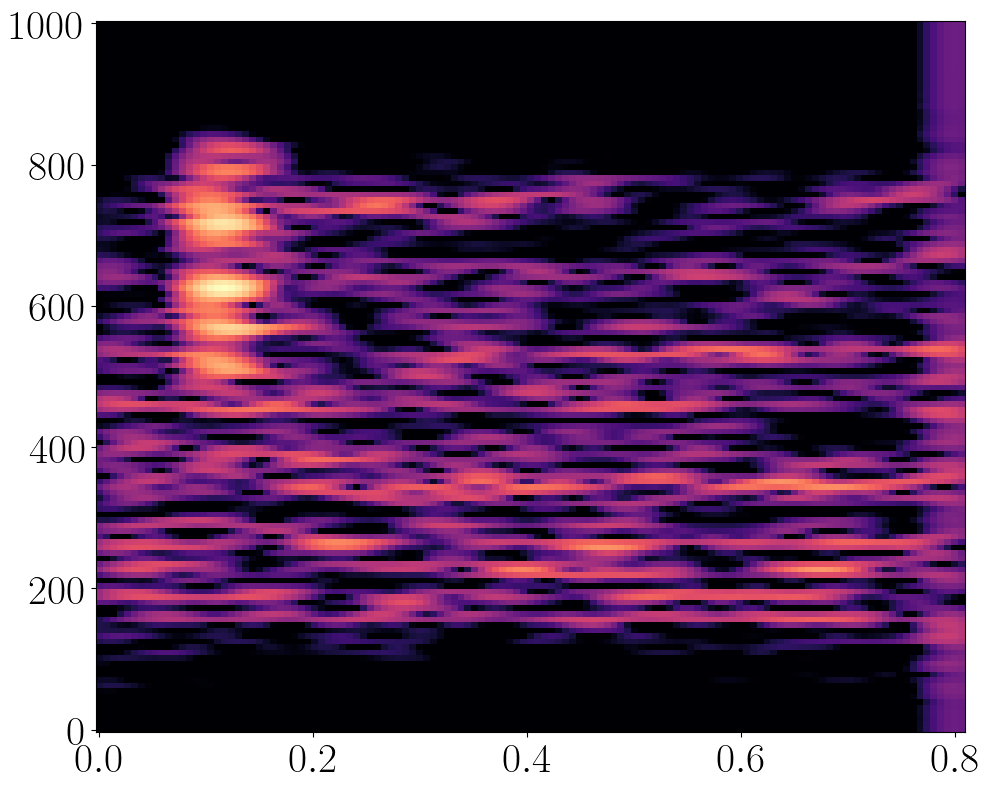

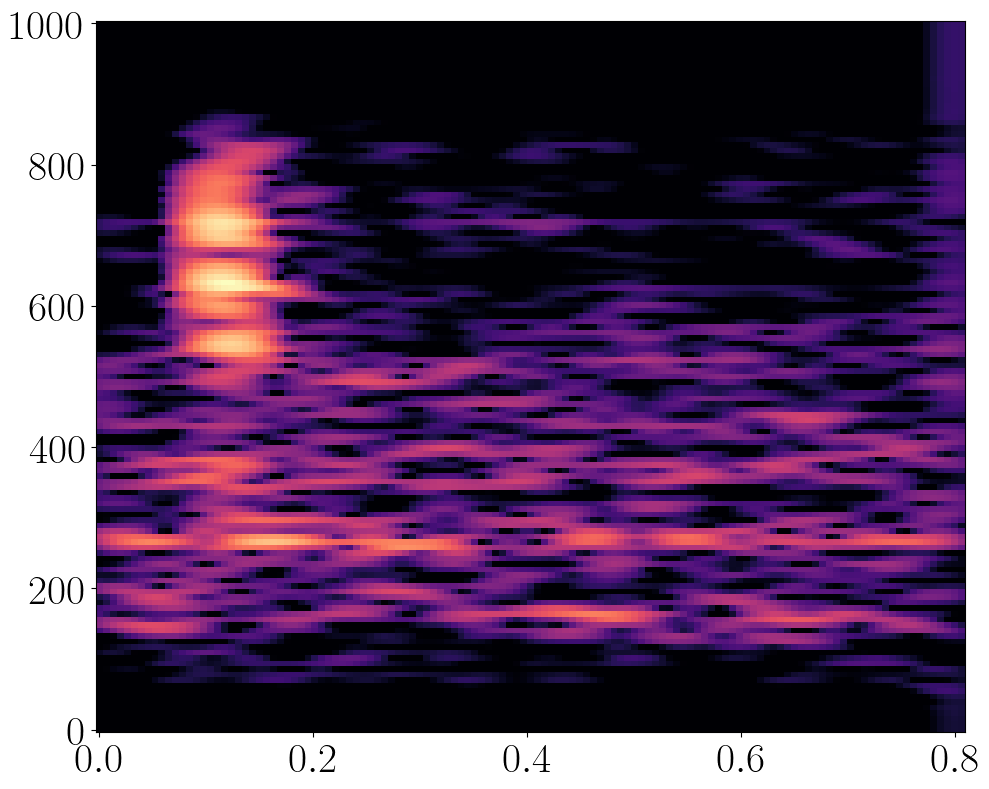

In [59]:
nperseg=2**8
# noverlap=nperseg-1
noverlap=int(nperseg*0.95)

print(f"nperseg = {nperseg}, noverlap={noverlap}")

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 2) 
t_win = t_ir[t_win_idx]
for i, h_idx in enumerate(ds_sig_selection.h_index.values):

    rolled_ir = impulse_responses[i] / impulse_responses[i].max()
    rolled_ir = np.roll(rolled_ir, n_roll)
    rolled_ir = rolled_ir[t_win_idx]

    f, t, Sxx = sp.stft(
        rolled_ir,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  
    )
    Sxx_db= 10*np.log10(abs(Sxx))

    plt.figure()
    plt.pcolormesh(
        t,
        f,
        10*np.log10(abs(Sxx)),
        cmap="magma",
        vmin=np.percentile(Sxx_db, 40),
        vmax=np.percentile(Sxx_db, 100),
    )


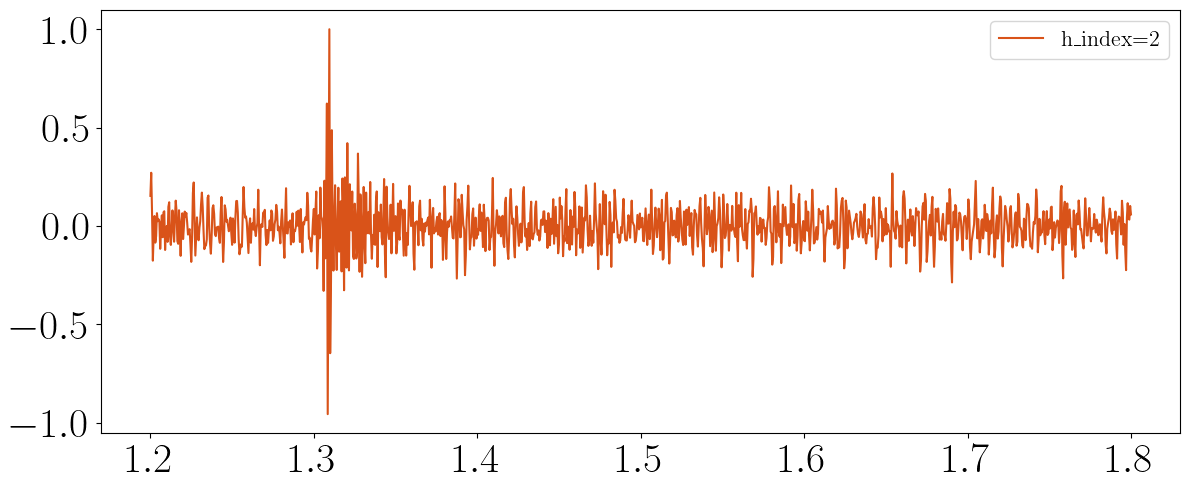

In [60]:
root_wav_save = r"C:\Users\baptiste.menetrier\Desktop\ressource\Bonnel_supp_publi_2020_warping\matlab_code\experimental_data\c_css_deconv"

t_ir = ds_sig_selection.t_ir
t_win_idx = (t_ir >= 1.2) & (t_ir <= 1.8)
t_win = t_ir[t_win_idx]

i = 1
h_idx = ds_sig_selection.h_index.values[i]

rolled_ir = impulse_responses[i] / impulse_responses[i].max()
rolled_ir = np.roll(rolled_ir, n_roll)
rolled_ir = rolled_ir[t_win_idx]

fig, axs = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
axs.plot(t_win, rolled_ir, label=f"h_index={h_idx}", color=color(i))
axs.legend()

# Save to wav
import scipy.io.wavfile as wavfile

fpath = os.path.join(root_wav_save, f"OBS{h_idx}_seq_{seq_id}_pulse_{pulse_id_selected}.wav")
wavfile.write(
    fpath,
    fs,
    rolled_ir,
)